In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from utils import fetch_baostock_data

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
back_test_config = {
    5: range(10, 15),
    10: range(20, 30),
    20: range(40, 60),
    60: range(120, 180)
}

In [3]:
def calc_price_bias(series: pd.Series, n: int = 20):
    ma = series.rolling(window=n).mean()
    bias = (series - ma) / ma
    return bias

def calc_momentum(series: pd.Series, n: int = 20):
    return series / series.shift(n) - 1

def calc_boll_breakout(series: pd.Series, n: int = 20, k: float = 2.0):
    mid_band = series.rolling(window=n).mean()

    std = series.rolling(window=n).std()

    upper_band = mid_band + k * std
    lower_band = mid_band - k * std

    breakthrough_index = (series - lower_band) / (upper_band - lower_band)

    return breakthrough_index

In [4]:
def calc_vol_mean(series_vol: pd.Series, n: int = 20):
    return series_vol.rolling(window=n).mean()

def calc_vol_bias(series_vol: pd.Series, n: int = 20):
    vol_mean = series_vol.rolling(window=n).mean()
    return (series_vol / vol_mean) - 1

def calc_price_vol_corr(series_close: pd.Series, series_vol: pd.Series, n: int = 20):
    return series_close.rolling(window=n).corr(series_vol)

In [5]:
def calc_new_high_ratio(series_high: pd.Series, n: int):
    is_new_high = series_high == series_high.rolling(window=n).max()
    return is_new_high.rolling(window=n).mean()

def calc_new_low_ratio(series_low: pd.Series, n: int):
    is_new_low = series_low == series_low.rolling(window=n).min()
    return is_new_low.rolling(window=n).mean()

def calc_ma_alignment_ratio(series_close: pd.Series, n: int):
    ma5 = series_close.rolling(window=5).mean()
    ma20 = series_close.rolling(window=20).mean()
    ma60 = series_close.rolling(window=60).mean()

    is_bullish = (ma5 > ma20) & (ma20 > ma60)
    return is_bullish.rolling(window=n).mean()

def calc_ma_alignment_bear_ratio(series_close: pd.Series, n: int):
    ma5 = series_close.rolling(window=5).mean()
    ma20 = series_close.rolling(window=20).mean()
    ma60 = series_close.rolling(window=60).mean()

    is_bearish = (ma5 < ma20) & (ma20 < ma60)

    return is_bearish.rolling(window=n).mean()

def calc_adx(series_high: pd.Series, series_low: pd.Series, series_close: pd.Series, n: int):
    h, l, c = series_high.squeeze(), series_low.squeeze(), series_close.squeeze()

    plus_dm = (h.diff()).clip(lower=0)
    minus_dm = (-l.diff()).clip(lower=0)

    tr = pd.concat([
        h - l,
        (h - c.shift()).abs(),
        (l - c.shift()).abs()
    ], axis=1).max(axis=1)

    atr = tr.rolling(n).mean()

    plus_di = 100 * (plus_dm.rolling(n).mean() / atr)
    minus_di = 100 * (minus_dm.rolling(n).mean() / atr)

    dx = (plus_di - minus_di).abs() / (plus_di + minus_di) * 100
    adx = dx.rolling(n).mean()

    return adx.rename(None)

In [6]:
def calc_price_volatility(series_close: pd.Series, n: int):
    returns = series_close.pct_change()
    return returns.rolling(window=n).std() * np.sqrt(252)

def calc_volume_volatility(series_vol: pd.Series, n: int):
    vol_change = series_vol.pct_change()
    return vol_change.rolling(window=n).std()

In [7]:
def plot_box(results_dict: dict, bench_sharpe: float, title: str = "夏普比率分布"):
    df_plot = pd.DataFrame(results_dict)

    plt.figure(figsize=(12, 7))

    df_plot.boxplot(grid=False,
                    patch_artist=False,
                    medianprops={'color': 'green', 'linewidth': 1.5},
                    showmeans=False)

    plt.axhline(y=0, color='grey', linestyle='--', label='Zero Line')

    plt.axhline(y=bench_sharpe, color='r', linestyle='--', label='Benchmark (Buy & Hold)')

    plt.title(title, fontsize=14)
    plt.ylabel('Sharpe Ratio', fontsize=12)
    plt.xlabel('Strategy / Factor Window', fontsize=12)
    plt.ylim(-1.5, 1.5)

    plt.xticks(rotation=45)

    plt.legend()
    plt.tight_layout()
    plt.show()

In [8]:
class StrategyBackTester:
    def __init__(self, strategy_name: str, test_config: dict,
                 start_date: str = '2010-01-01', end_date: str = '2026-01-01'):

        self.start_date = start_date
        self.end_date = end_date
        self.strategy_name = strategy_name
        self.test_config = test_config
        self.data = self._get_daily_index_data()

    def _get_daily_index_data(self):
        _data = fetch_baostock_data("sh.000300", self.start_date, self.end_date)

        _data['benchmark'] = (1 + _data['pctChg']).cumprod()

        return _data

    def _calc_rolling_indicators(self, input_data, indicator_name: str, indicator_calculator) -> pd.DataFrame:
        result = pd.DataFrame(index=input_data[0].index)

        for n in self.test_config.keys():
            result[f"{indicator_name}_{n}"] = indicator_calculator(*input_data, n)

        return result

    @property
    def sharpe_benchmark(self):
        bench_df = self.data[['pctChg']].dropna()
        sharpe_series = self._calc_sharpe_ratio(bench_df)
        return sharpe_series.iloc[0]

    @staticmethod
    def boll_strategy(indicator: pd.Series, window):
        k = 2
        mb = indicator.rolling(window=window).mean()
        std = indicator.rolling(window=window).std()
        up = mb + k * std
        dn = mb - k * std

        buy_signal = indicator > up
        exit_signal = indicator < dn

        _signal = pd.Series(np.nan, index=indicator.index)
        _signal[buy_signal] = 1
        _signal[exit_signal] = -1

        _signal = _signal.ffill().fillna(0)
        return _signal

    @staticmethod
    def sma_strategy(indicator: pd.Series, window: int):
        ma_indicator = indicator.rolling(window=window).mean()

        _signal = pd.Series(0, index=indicator.index)
        _signal[indicator > ma_indicator] = 1
        _signal[indicator < ma_indicator] = -1

        _signal[ma_indicator.isna()] = 0
        return _signal

    @staticmethod
    def mom_strategy(indicator: pd.Series, window: int):
        past_indicator = indicator.shift(window)

        _signal = pd.Series(0, index=indicator.index)
        _signal[indicator > past_indicator] = 1
        _signal[indicator < past_indicator] = -1

        _signal[past_indicator.isna()] = 0
        return _signal

    def run_strategy(self, field_names, indicator_name: str, indicator_calculator):
        if isinstance(field_names, str):
            fields = [field_names]
        else:
            fields = field_names

        input_data = [self.data[f] for f in fields]

        indicators = self._calc_rolling_indicators(input_data, indicator_name, indicator_calculator)

        _results = {}

        method = getattr(self, f"{self.strategy_name}_strategy")

        for n, window_list in back_test_config.items():
            signals_dict = {}

            indicator_index = f"{indicator_name}_{n}"
            indicator = indicators[indicator_index]

            for window in window_list:
                signals_dict[window] = method(indicator, window)

            signals = pd.DataFrame(signals_dict)

            return_df = self._calc_return(signals)
            reverse_return_df = self._calc_return(-signals)

            _results[indicator_index.upper()] = self._calc_sharpe_ratio(return_df)
            _results[f"R{indicator_index.upper()}"] = self._calc_sharpe_ratio(reverse_return_df)

        return _results

    def plot_strategy_performance(self, field_names, indicator_name: str,
                                  indicator_calculator, n: int, window: int,
                                  is_reverse: bool = False):
        if isinstance(field_names, str):
            fields = [field_names]
        else:
            fields = field_names

        input_data = [self.data[f].squeeze() for f in fields]
        indicator = indicator_calculator(*input_data, n)

        strategy_method = getattr(self, f"{self.strategy_name}_strategy")
        signal = strategy_method(indicator, window)

        if is_reverse:
            signal = -signal

        signal_df = pd.DataFrame({'temp_sig': signal})

        net_return_df = self._calc_return(signal_df)

        daily_rtn = net_return_df['temp_sig']

        strategy_cum_rtn = (1 + daily_rtn).cumprod()
        benchmark_cum_rtn = self.data['benchmark']

        title = f"{self.strategy_name.upper()} | {indicator_name}(n={n}, w={window}) {'[REVERSE]' if is_reverse else ''}"
        self._plot_equity_curve(strategy_cum_rtn, benchmark_cum_rtn, title)

    def get_strategy_signal(self, field_names, factor_name: str,
                            indicator_calculator, n: int, window: int,
                            is_reverse: bool = False) -> pd.Series:
        if isinstance(field_names, str):
            fields = [field_names]
        else:
            fields = field_names

        input_data = [self.data[f].squeeze() for f in fields]

        indicator = indicator_calculator(*input_data, n)

        strategy_method = getattr(self, f"{self.strategy_name}_strategy")
        signal = strategy_method(indicator, window)

        if is_reverse:
            signal = -signal

        signal_series = pd.Series(signal, index=self.data.index, name=factor_name)

        return signal_series

    def plot_signal_performance(self, final_signal,
                                title: str = "Combined Strategy"):
        signal_df = pd.DataFrame({'temp_sig': final_signal}, index=self.data.index)

        net_return_df = self._calc_return(signal_df)

        daily_rtn = net_return_df['temp_sig']

        strategy_cum_rtn = (1 + daily_rtn).cumprod()
        benchmark_cum_rtn = self.data['benchmark']

        self._plot_equity_curve(strategy_cum_rtn, benchmark_cum_rtn, title)

    @staticmethod
    def _plot_equity_curve(strategy_equity, benchmark_equity, title):
        strategy_dd = (strategy_equity / strategy_equity.cummax()) - 1
        benchmark_dd = (benchmark_equity / benchmark_equity.cummax()) - 1

        fig, ax1 = plt.subplots(figsize=(12, 7))
        dates = strategy_equity.index

        ax1.plot(dates, strategy_equity, label='Strategy Equity',
                 color='#1E90FF', linewidth=2)
        ax1.plot(dates, benchmark_equity, label='Benchmark (300.SS)',
                 color='#FF4500', linestyle='--', alpha=0.8)

        ax1.set_ylabel('Cumulative Return', fontsize=10)
        ax1_min = min(strategy_equity.min(), benchmark_equity.min())
        ax1_max = max(strategy_equity.max(), benchmark_equity.max())
        ax1.set_ylim(ax1_min * 0.7, ax1_max * 1.1) # 底部留出大量空白给回撤
        ax1.grid(True, alpha=0.2)

        ax2 = ax1.twinx()

        ax2.fill_between(dates, strategy_dd, 0, label='Strategy Drawdown',
                         color='grey', alpha=0.2)

        ax2.plot(dates, benchmark_dd, color='black', linewidth=0.5,
                 alpha=0.3, label='Benchmark Drawdown')

        ax2.set_ylabel('Drawdown', fontsize=10)

        ax2.set_ylim(-1.0, 0.1)

        ax2.grid(False)

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right',
                   frameon=True, fontsize=9)

        plt.title(title, fontsize=14, fontweight='bold')
        ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        fig.autofmt_xdate()

        plt.tight_layout()
        plt.show()

    def _calc_return(self, signals: pd.DataFrame, initial_cash=1000000, lot_size=100,
                 slippage=0.002, limit_threshold=0.098, return_type='return') -> pd.DataFrame:
        buy_fee = 0.0003
        sell_fee = 0.0013

        opens = self.data['Open'].values
        closes = self.data['Close'].values
        results = {}

        for col in signals.columns:
            sig = signals[col].values
            dates = signals.index

            cash = initial_cash
            shares = 0.0
            last_buy_date = None
            daily_total_value = [initial_cash]

            for i in range(1, len(sig)):
                target_signal = sig[i-1]
                price_open = opens[i]
                prev_close = closes[i-1]
                current_date = dates[i]

                if pd.isna(price_open) or price_open <= 0 or pd.isna(prev_close):
                    price_close = closes[i] if not pd.isna(closes[i]) else closes[i-1]
                    daily_total_value.append(cash + (shares * price_close))
                    continue

                buy_price = price_open * (1 + slippage)
                sell_price = price_open * (1 - slippage)

                # 情况A：买入指令 且 当前空仓
                if target_signal == 1 and shares == 0:
                    is_limit_up = price_open >= prev_close * (1 + limit_threshold)

                    if not is_limit_up:
                        max_shares = cash / (buy_price * (1 + buy_fee))
                        actual_shares = int(max_shares // lot_size) * lot_size

                        if actual_shares > 0:
                            shares = actual_shares
                            trade_amount = shares * buy_price
                            fee_amount = trade_amount * buy_fee
                            cash -= (trade_amount + fee_amount)
                            last_buy_date = current_date

                # 情况B：卖出指令 且 当前持仓
                elif target_signal <= 0 < shares:
                    is_limit_down = price_open <= prev_close * (1 - limit_threshold)
                    can_sell_today = (last_buy_date is not None and current_date > last_buy_date)

                    if not is_limit_down and can_sell_today:
                        trade_amount = shares * sell_price
                        fee_amount = trade_amount * sell_fee
                        cash += (trade_amount - fee_amount)
                        shares = 0.0

                price_close = closes[i]
                if pd.isna(price_close) or price_close <= 0:
                    price_close = prev_close

                current_value = cash + (shares * price_close)
                daily_total_value.append(current_value)

            if shares > 0:
                final_price = closes[-1]
                final_trade_amount = shares * final_price
                final_fee = final_trade_amount * sell_fee
                final_cash = cash + final_trade_amount - final_fee
                daily_total_value[-1] = final_cash

            account_series = pd.Series(daily_total_value, index=dates)

            if return_type == 'value':
                results[col] = account_series
            elif return_type == 'nav':
                results[col] = account_series / initial_cash
            else:
                results[col] = account_series.pct_change().fillna(0)

        return pd.DataFrame(results)

    @staticmethod
    def _calc_sharpe_ratio(df: pd.DataFrame, rf=0.02) -> pd.Series:
        excess_returns = df - (rf / 252)

        mean_excess = excess_returns.mean()
        std_excess = excess_returns.std()

        sharpe = (mean_excess / std_excess) * (252 ** 0.5)

        return sharpe

In [9]:
boll = StrategyBackTester('boll', back_test_config)
mom = StrategyBackTester('mom', back_test_config)
sma = StrategyBackTester('sma', back_test_config)

### 筛选因子

#### 价格指标

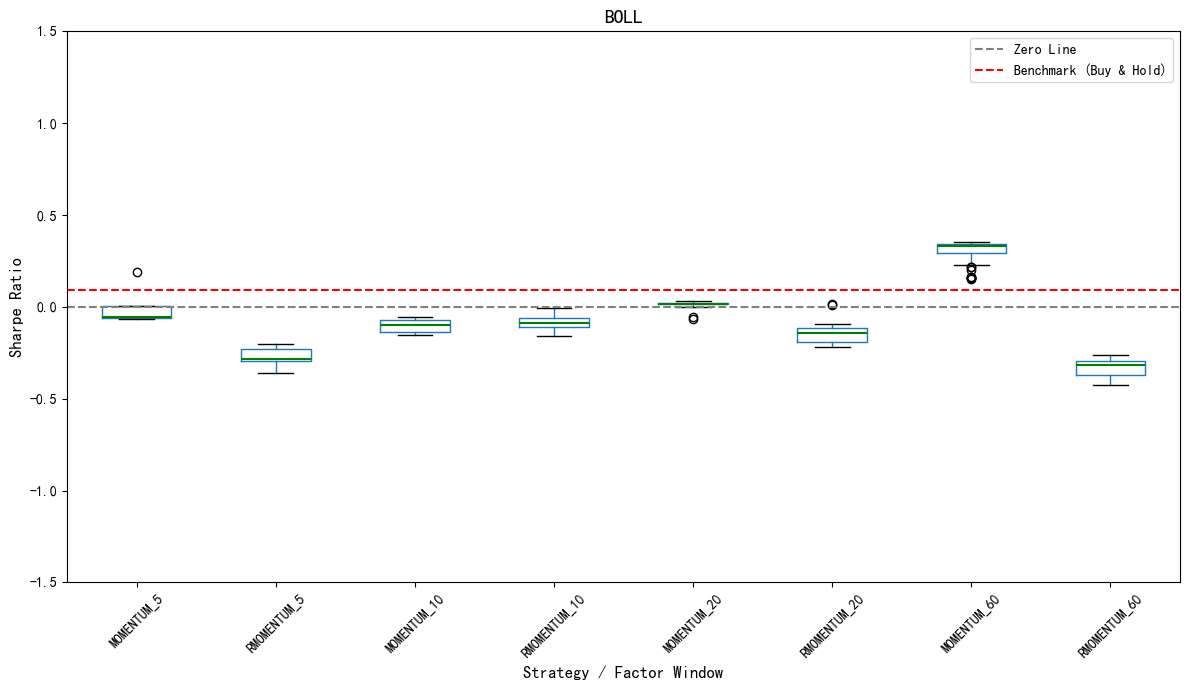

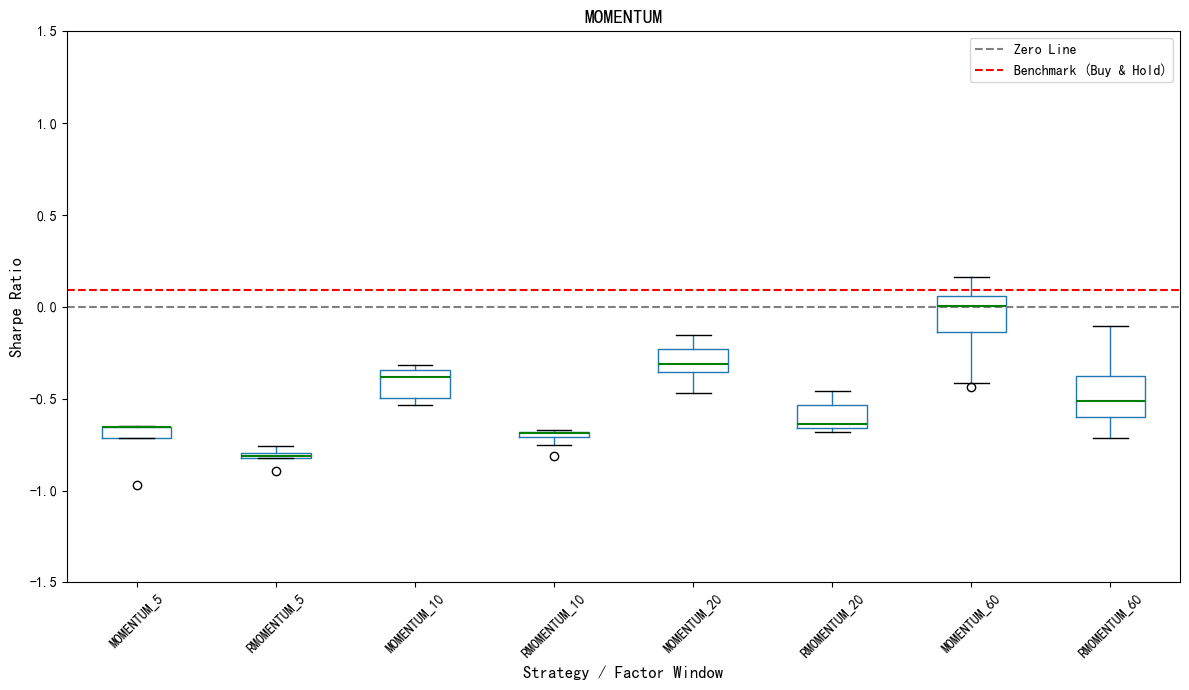

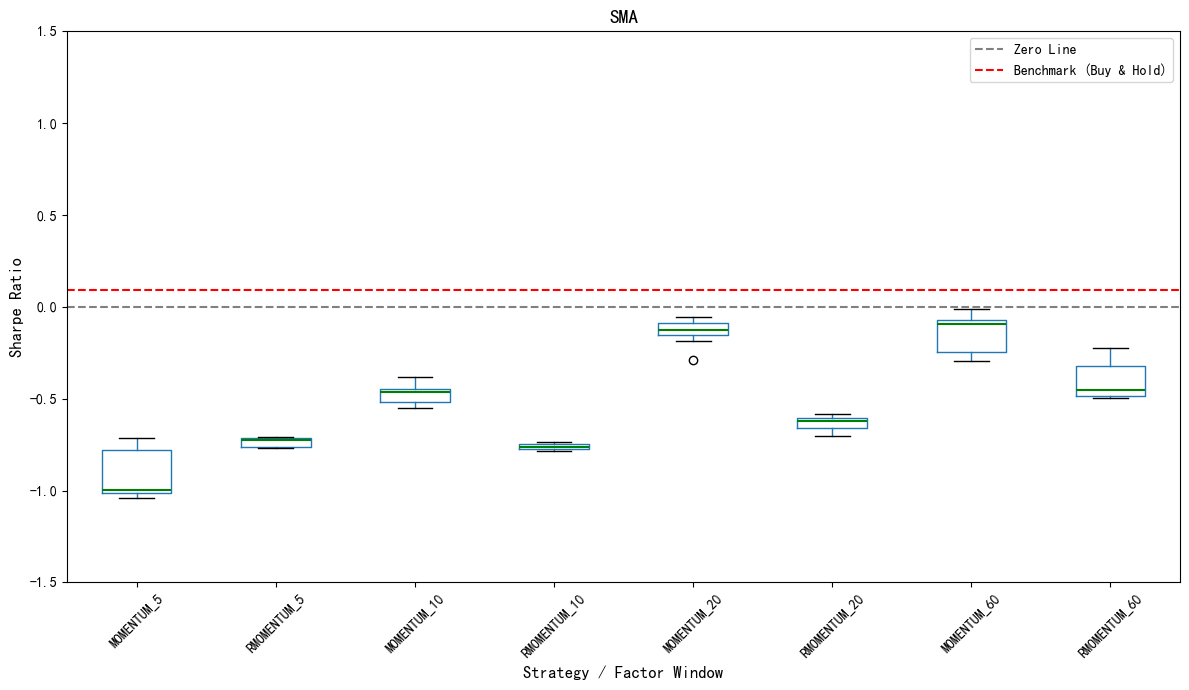

In [10]:
# 累计收益
boll_results = boll.run_strategy("Close", 'momentum', calc_momentum)
mom_results = mom.run_strategy("Close", 'momentum', calc_momentum)
sma_results = sma.run_strategy("Close", 'momentum', calc_momentum)

plot_box(boll_results, boll.sharpe_benchmark, "BOLL")
plot_box(mom_results, mom.sharpe_benchmark, "MOMENTUM")
plot_box(sma_results, sma.sharpe_benchmark, "SMA")

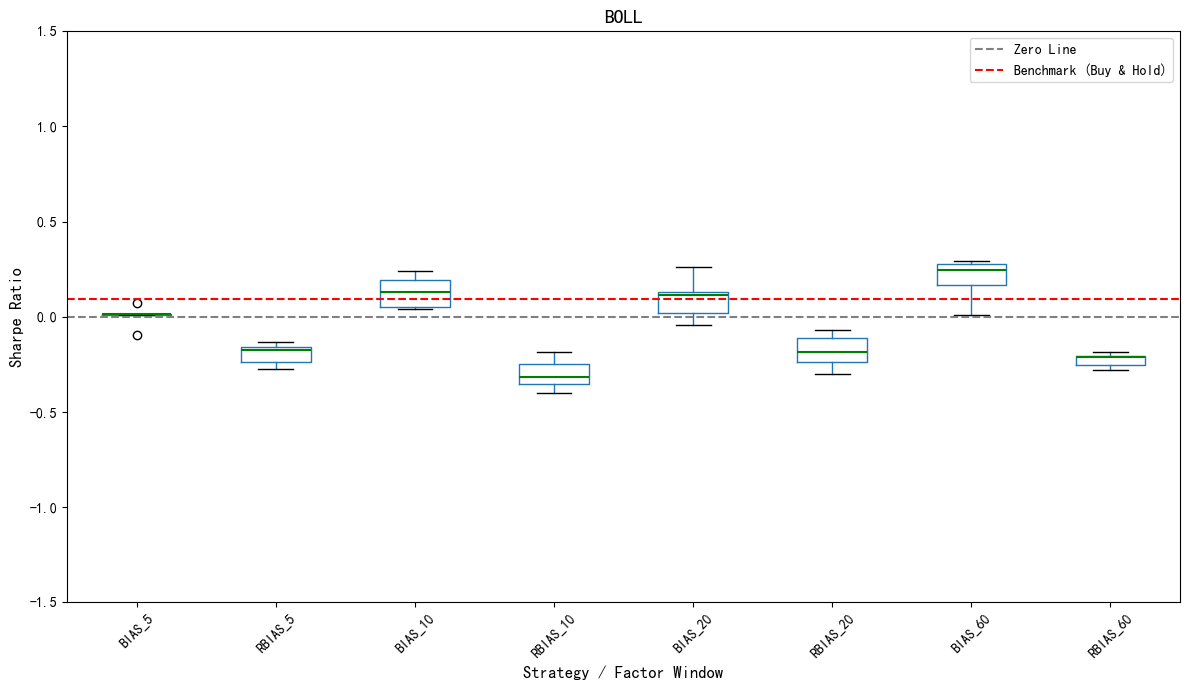

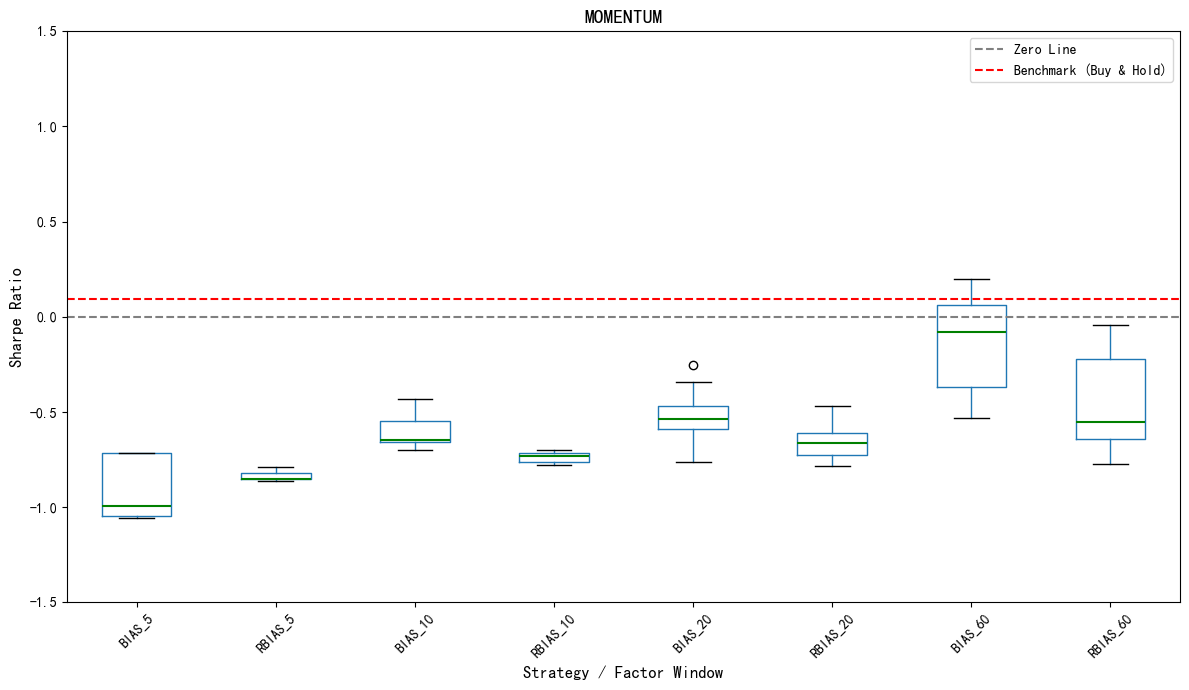

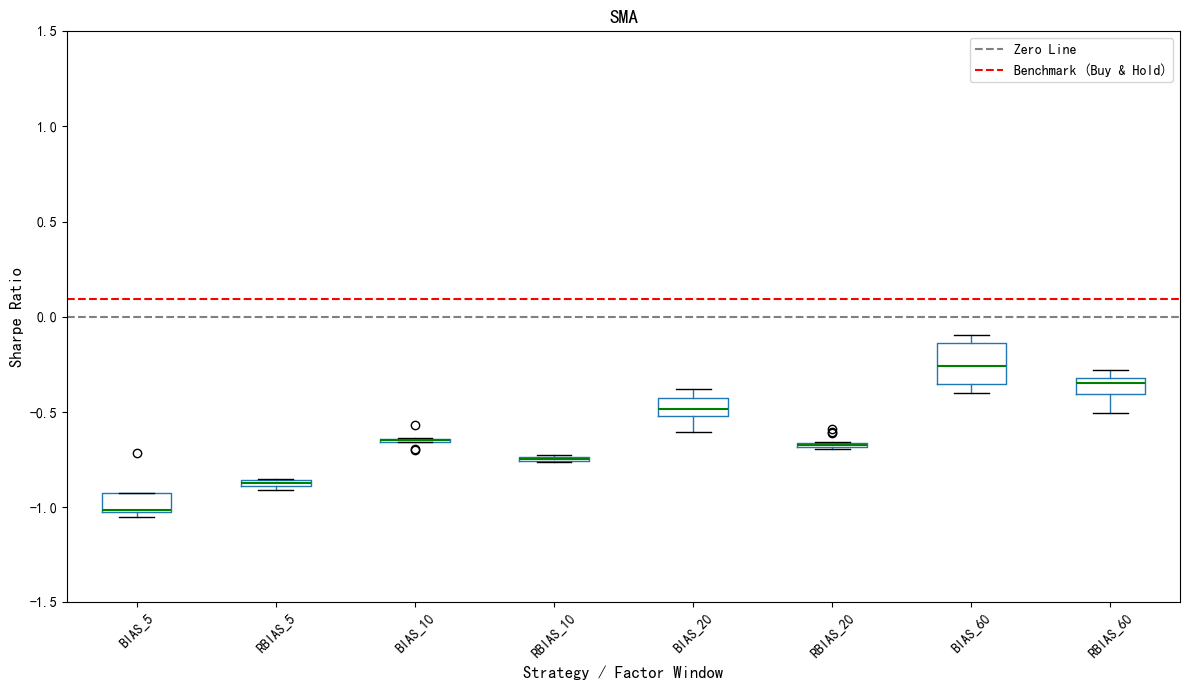

In [11]:
# 价格乖离率
boll_results = boll.run_strategy("Close", 'bias', calc_price_bias)
mom_results = mom.run_strategy("Close", 'bias', calc_price_bias)
sma_results = sma.run_strategy("Close", 'bias', calc_price_bias)

plot_box(boll_results, boll.sharpe_benchmark, "BOLL")
plot_box(mom_results, mom.sharpe_benchmark, "MOMENTUM")
plot_box(sma_results, sma.sharpe_benchmark, "SMA")

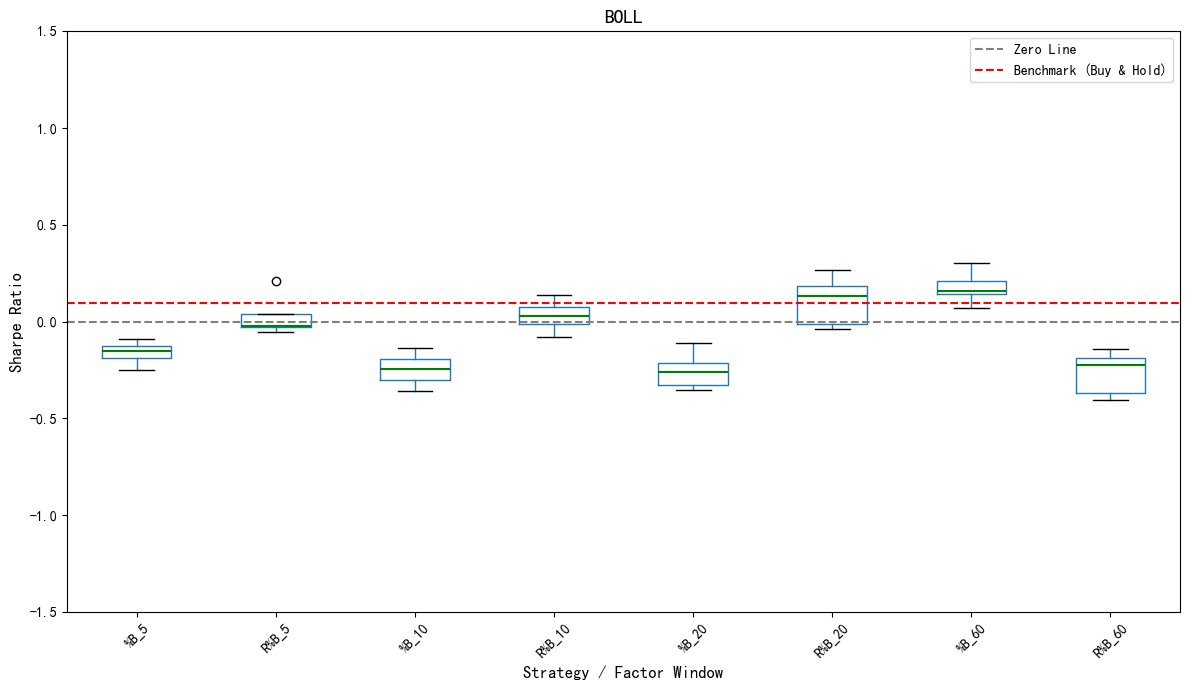

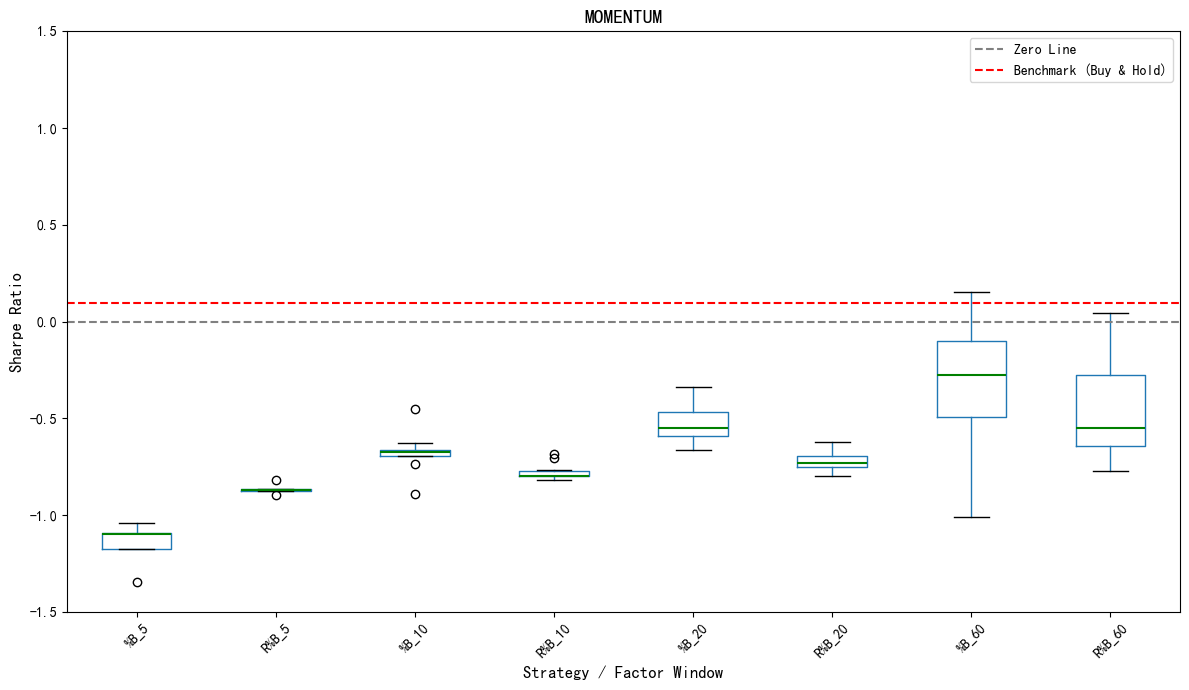

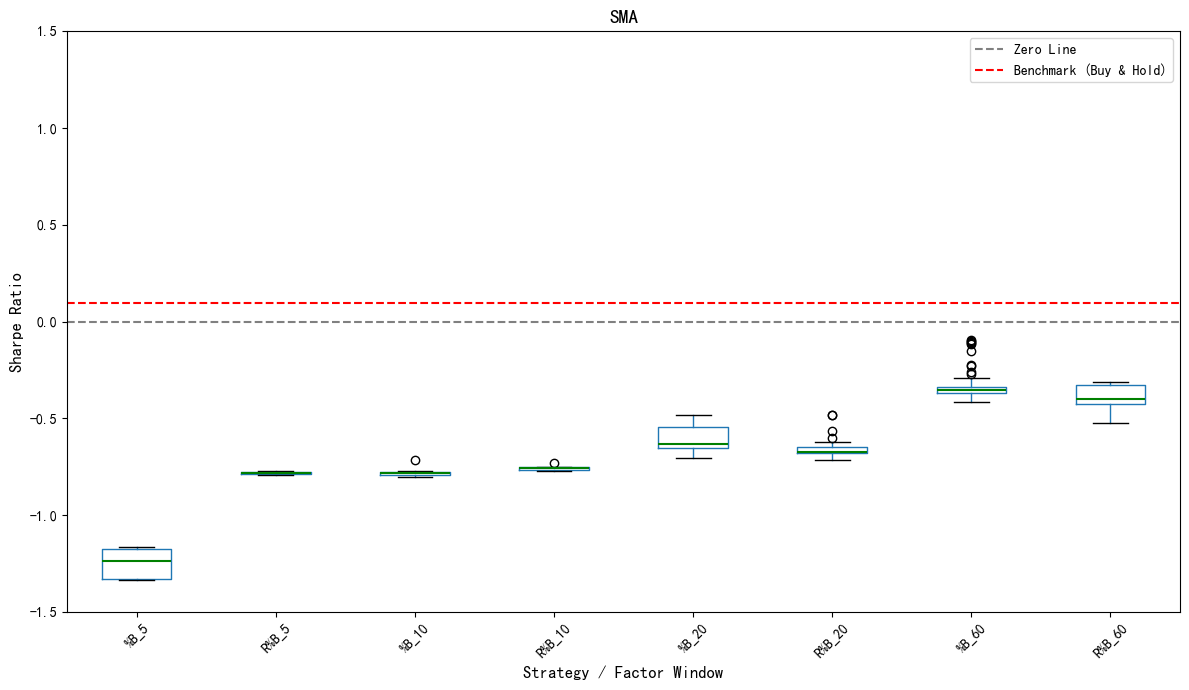

In [12]:
# 现价相对N日布林带通道的位置
boll_results = boll.run_strategy("Close", '%B', calc_boll_breakout)
mom_results = mom.run_strategy("Close", '%B', calc_boll_breakout)
sma_results = sma.run_strategy("Close", '%B', calc_boll_breakout)

plot_box(boll_results, boll.sharpe_benchmark, "BOLL")
plot_box(mom_results, mom.sharpe_benchmark, "MOMENTUM")
plot_box(sma_results, sma.sharpe_benchmark, "SMA")

#### 量能指标

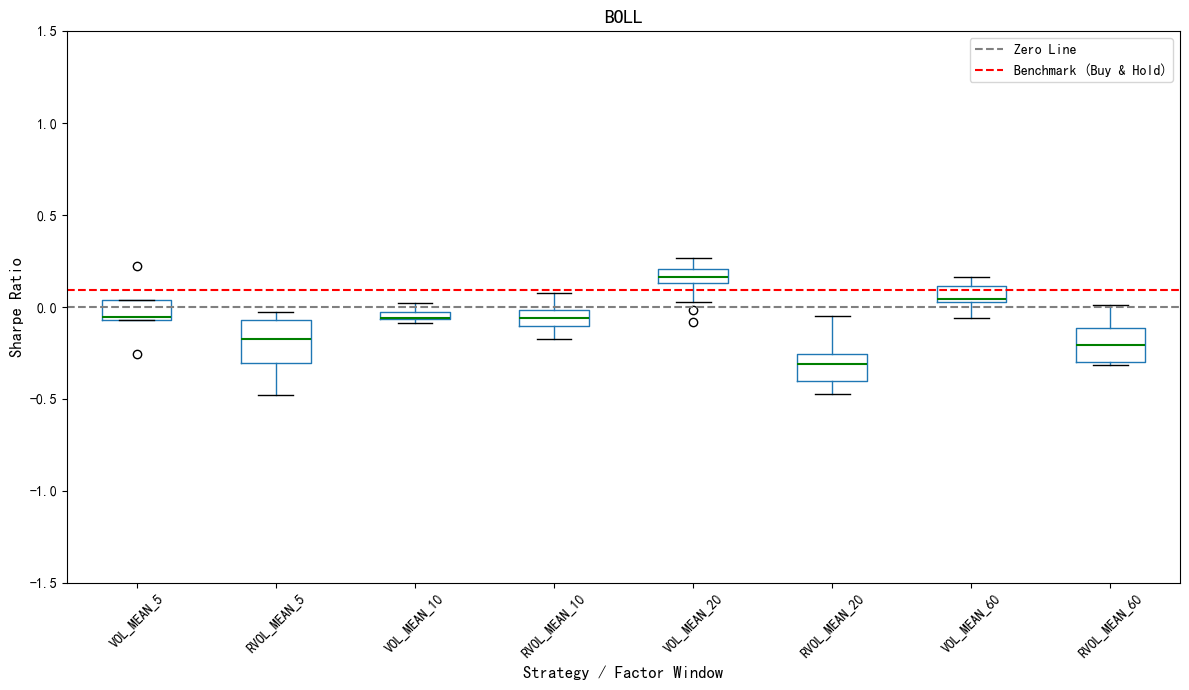

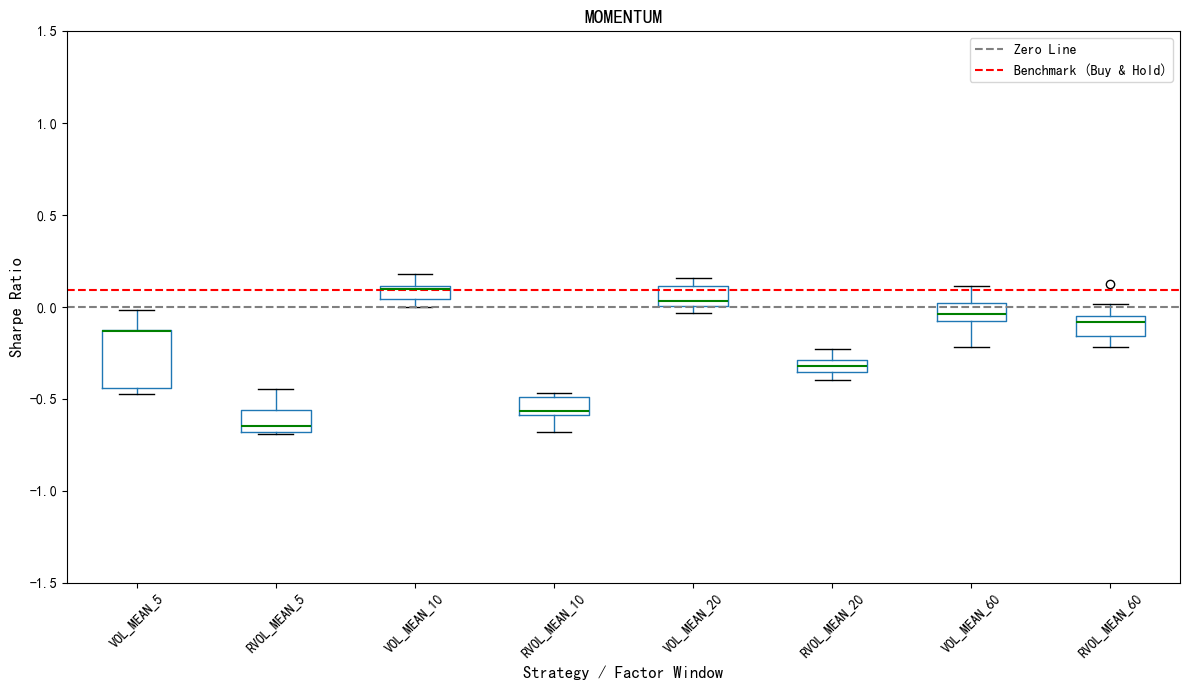

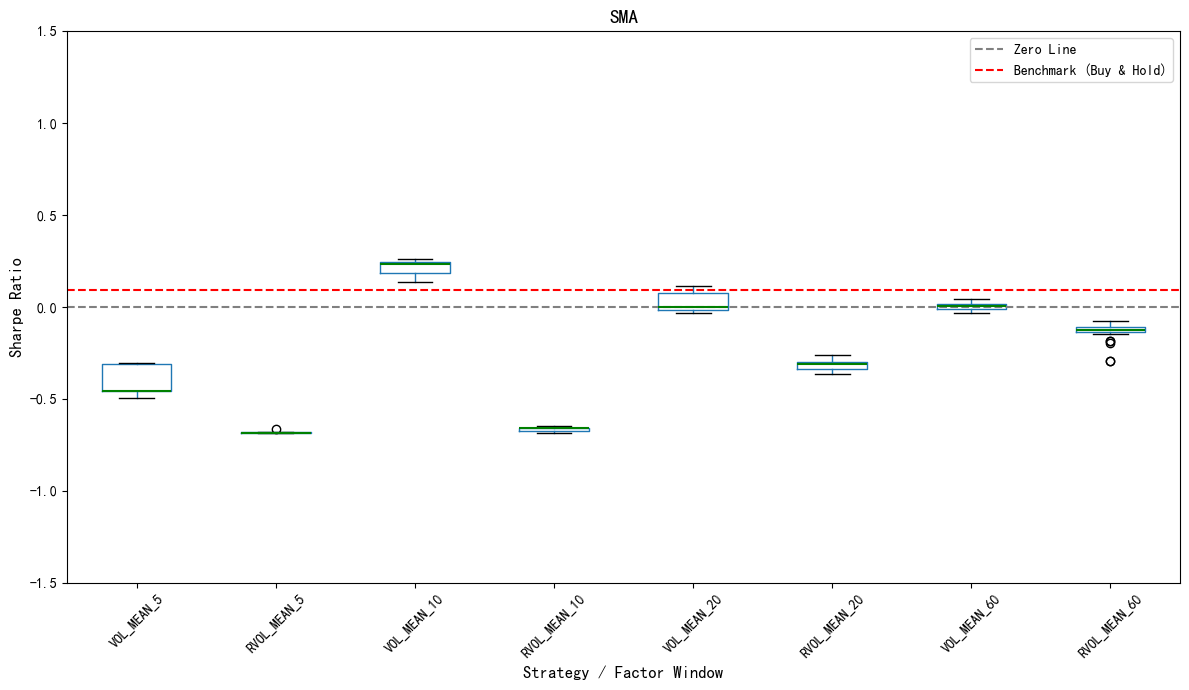

In [13]:
# 成交量 N 日均值
boll_results = boll.run_strategy("Volume", 'vol_mean', calc_vol_mean)
mom_results = mom.run_strategy("Volume", 'vol_mean', calc_vol_mean)
sma_results = sma.run_strategy("Volume", 'vol_mean', calc_vol_mean)

plot_box(boll_results, boll.sharpe_benchmark, "BOLL")
plot_box(mom_results, mom.sharpe_benchmark, "MOMENTUM")
plot_box(sma_results, sma.sharpe_benchmark, "SMA")

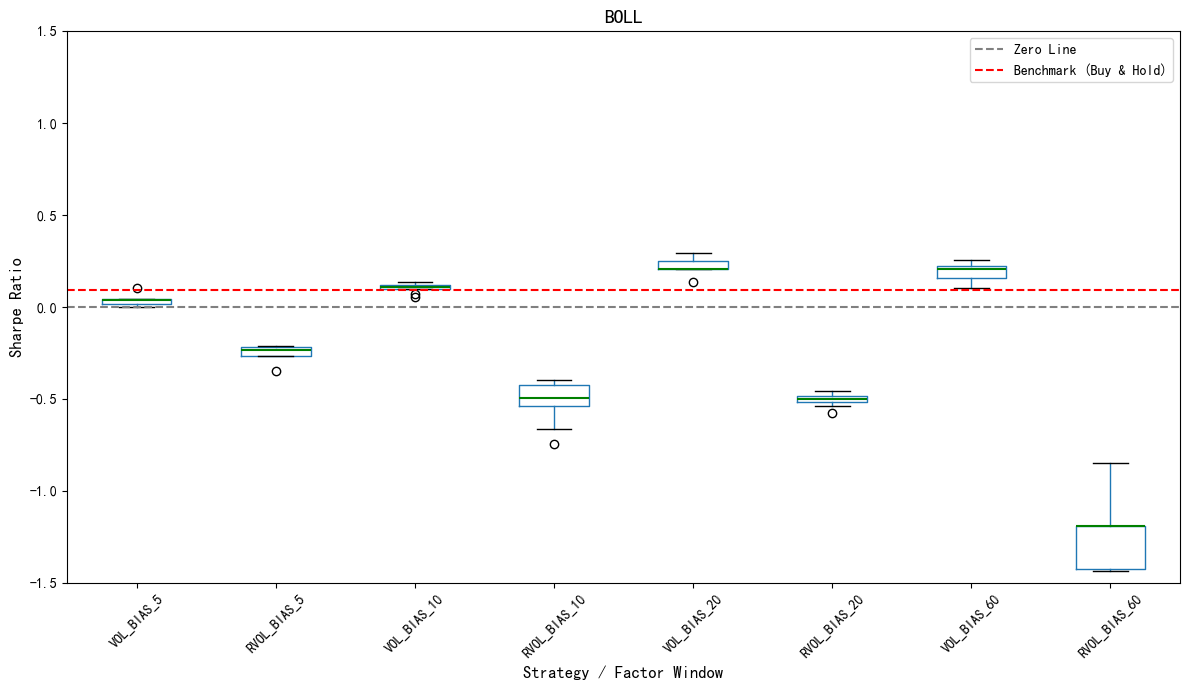

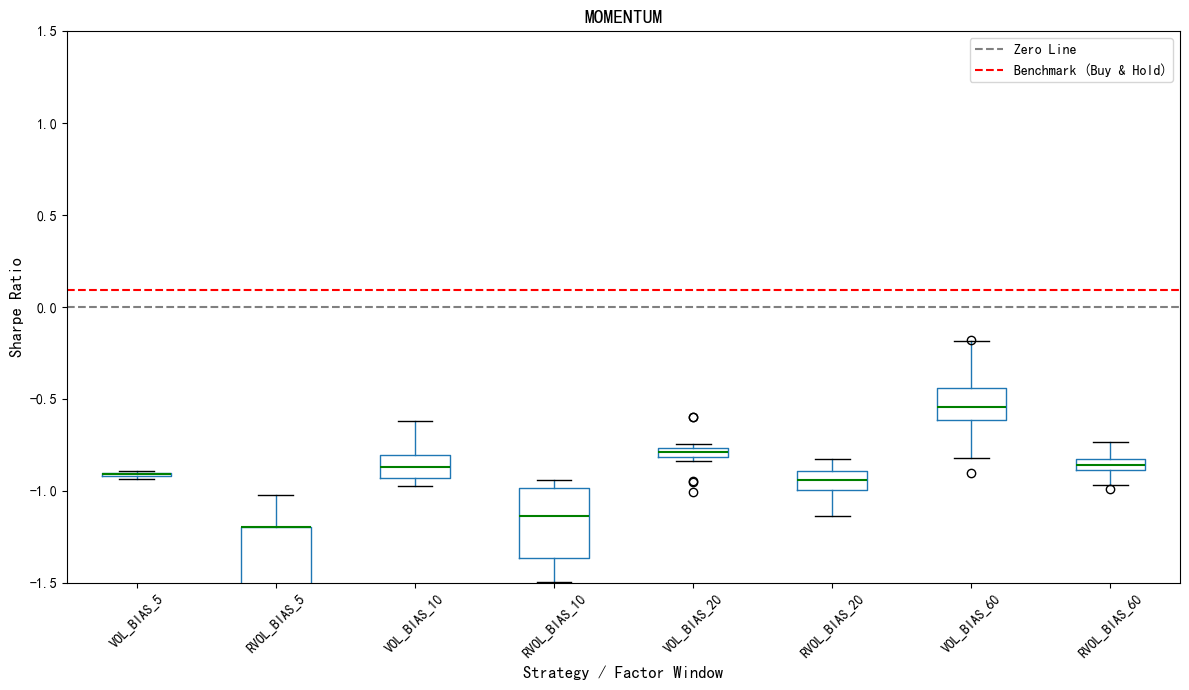

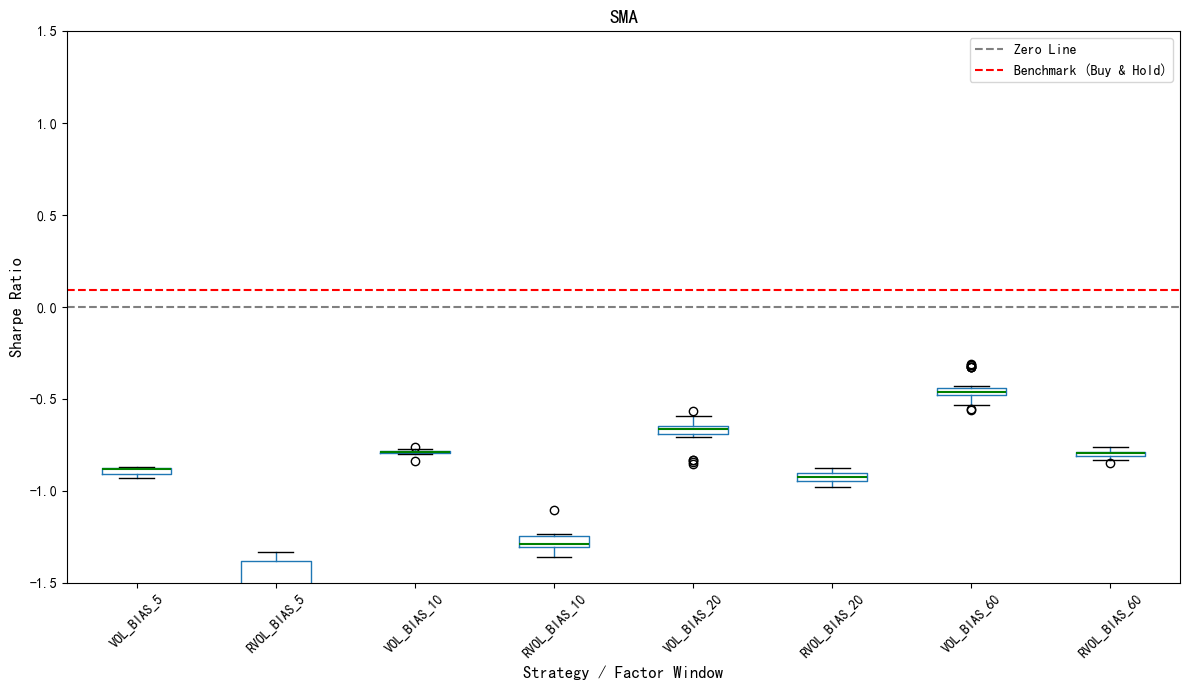

In [14]:
# 成交量 N 日乖离率
boll_results = boll.run_strategy("Volume", 'vol_bias', calc_vol_bias)
mom_results = mom.run_strategy("Volume", 'vol_bias', calc_vol_bias)
sma_results = sma.run_strategy("Volume", 'vol_bias', calc_vol_bias)

plot_box(boll_results, boll.sharpe_benchmark, "BOLL")
plot_box(mom_results, mom.sharpe_benchmark, "MOMENTUM")
plot_box(sma_results, sma.sharpe_benchmark, "SMA")

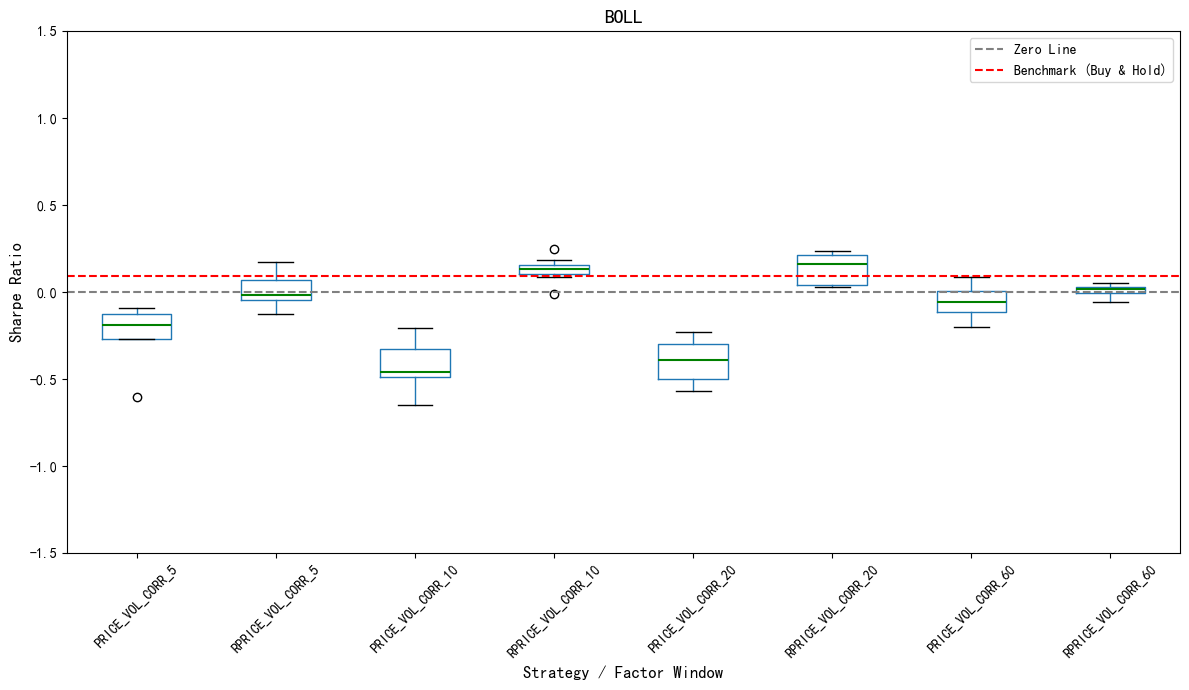

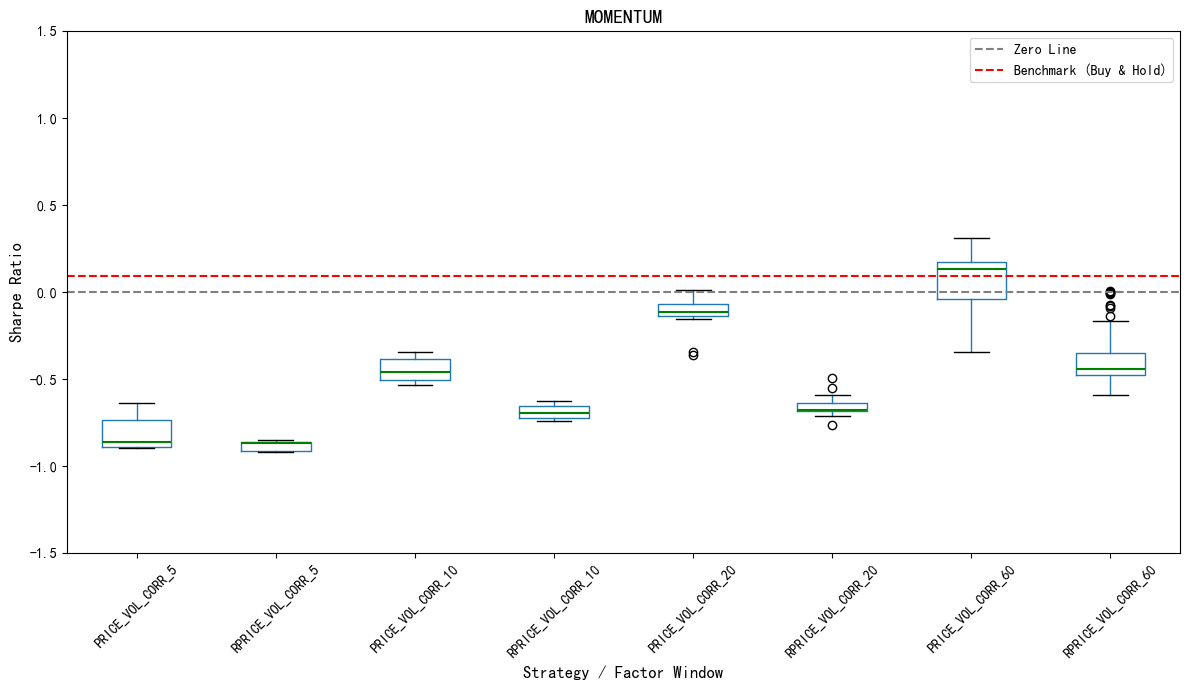

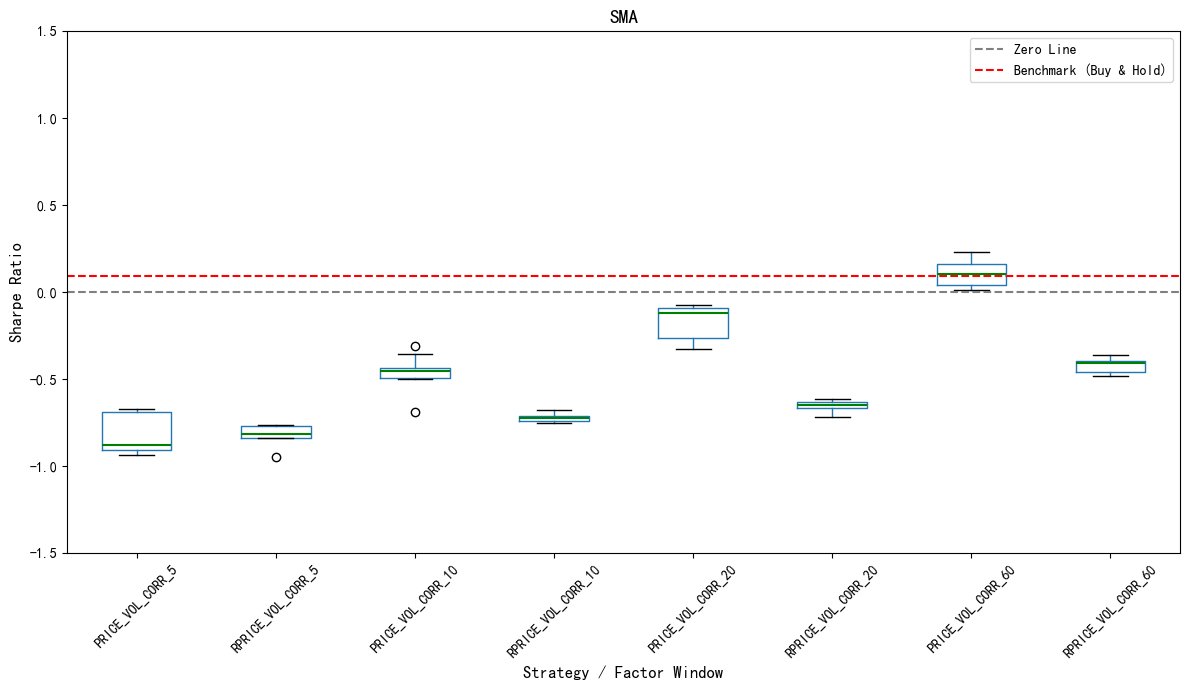

In [15]:
# N 日量价秩相关系数
boll_results = boll.run_strategy(["Close", "Volume"], 'price_vol_corr', calc_price_vol_corr)
mom_results = mom.run_strategy(["Close", "Volume"], 'price_vol_corr', calc_price_vol_corr)
sma_results = sma.run_strategy(["Close", "Volume"], 'price_vol_corr', calc_price_vol_corr)

plot_box(boll_results, boll.sharpe_benchmark, "BOLL")
plot_box(mom_results, mom.sharpe_benchmark, "MOMENTUM")
plot_box(sma_results, sma.sharpe_benchmark, "SMA")

#### 趋势

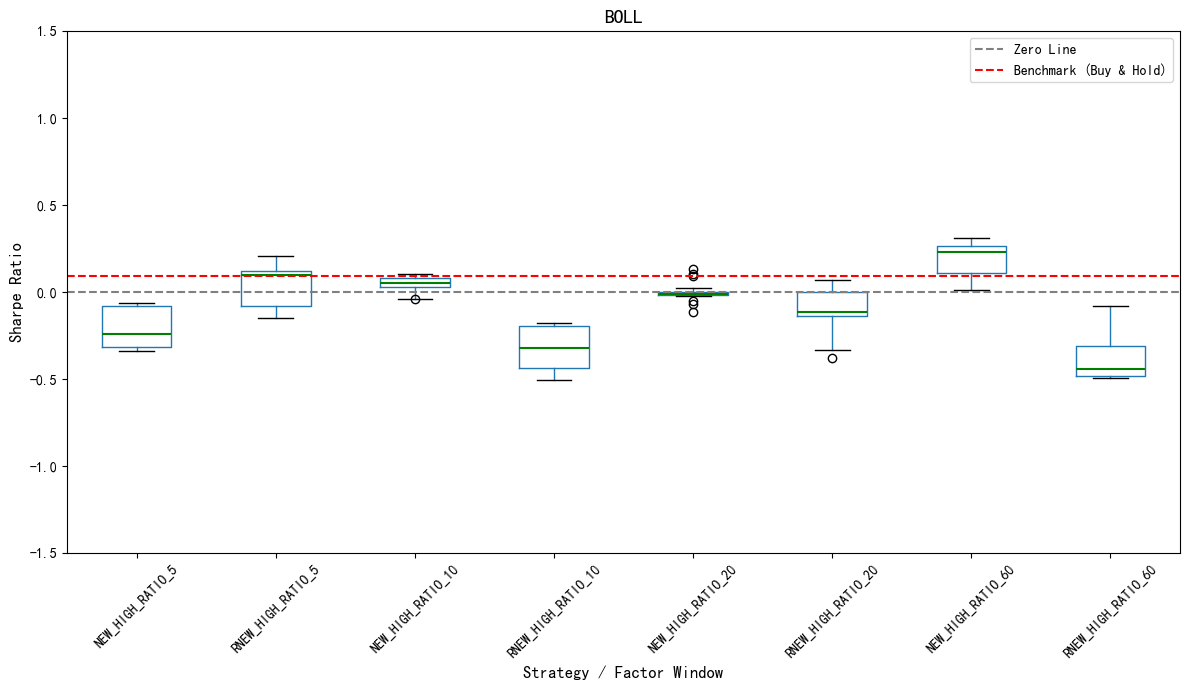

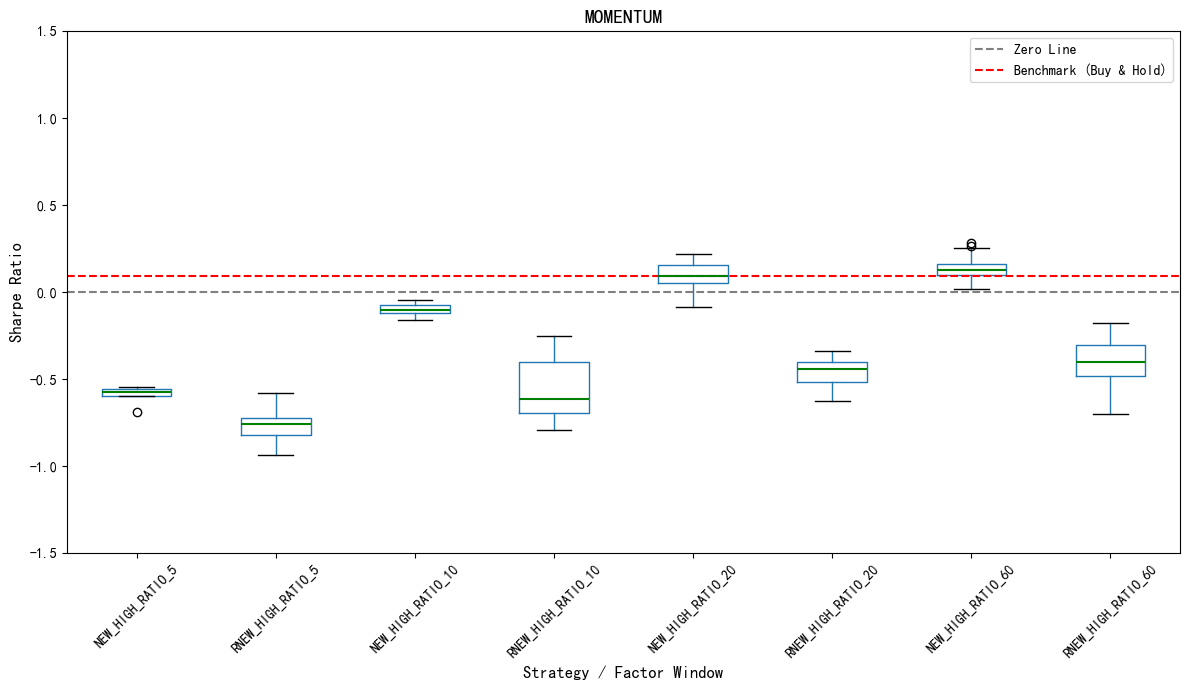

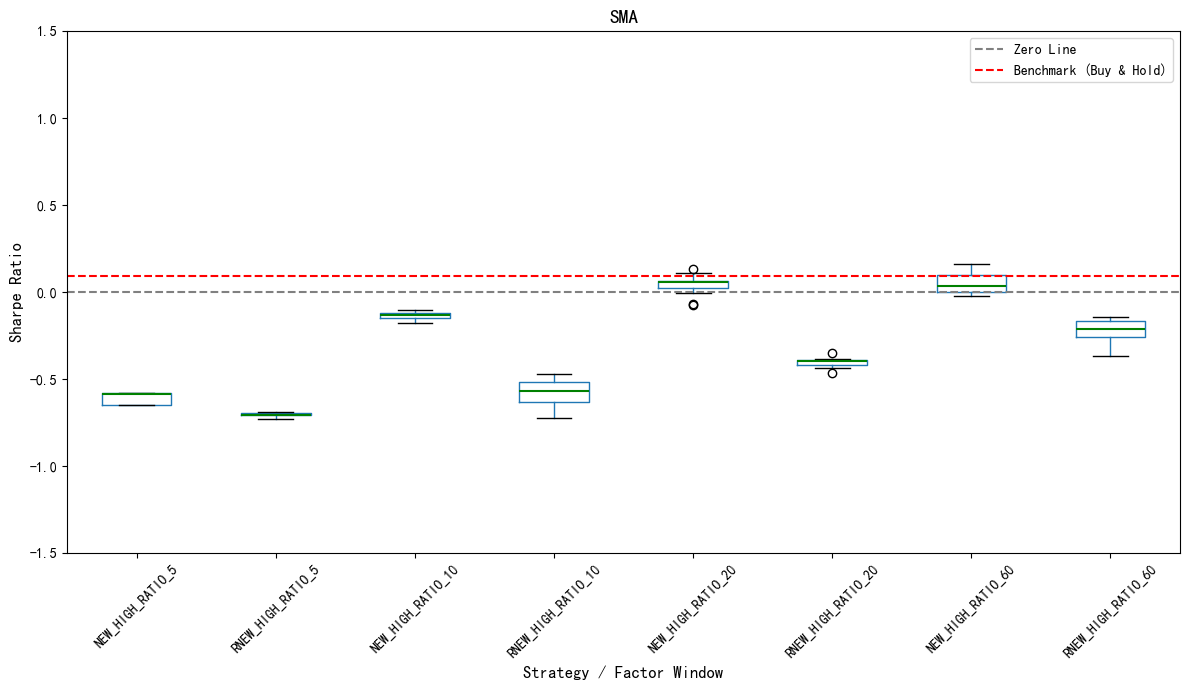

In [16]:
# 趋势新高占比
boll_results = boll.run_strategy("High", "New_High_Ratio", calc_new_high_ratio)
mom_results = mom.run_strategy("High", "New_High_Ratio", calc_new_high_ratio)
sma_results = sma.run_strategy("High", "New_High_Ratio", calc_new_high_ratio)

plot_box(boll_results, boll.sharpe_benchmark, "BOLL")
plot_box(mom_results, mom.sharpe_benchmark, "MOMENTUM")
plot_box(sma_results, sma.sharpe_benchmark, "SMA")

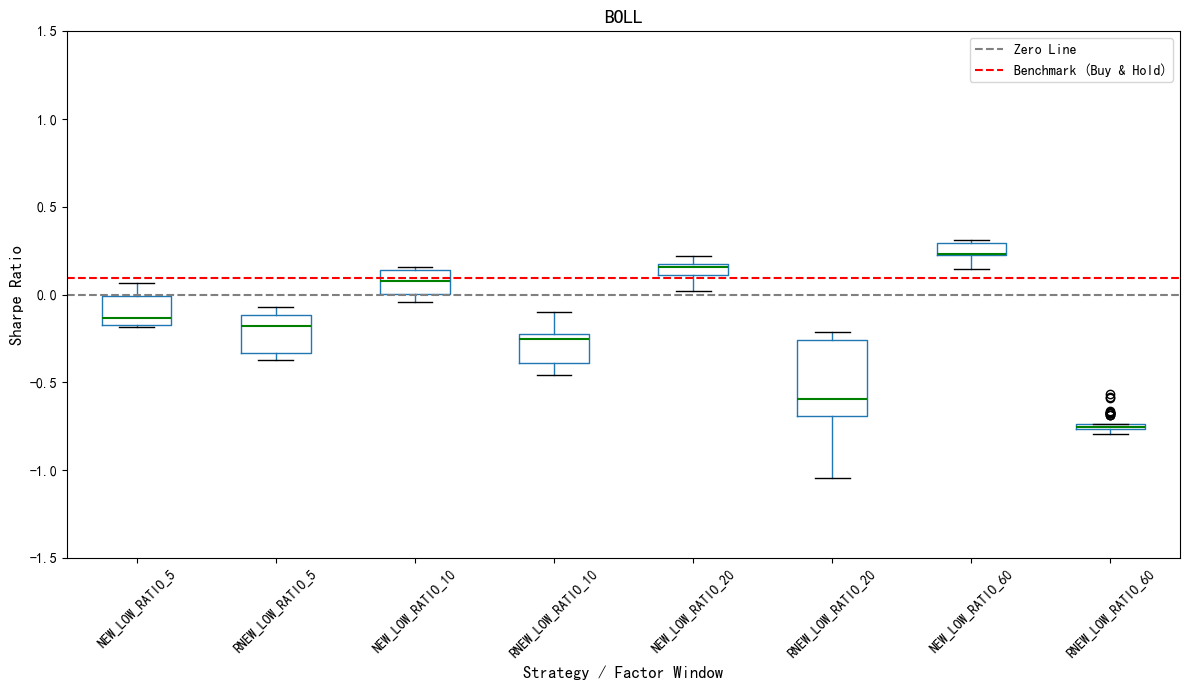

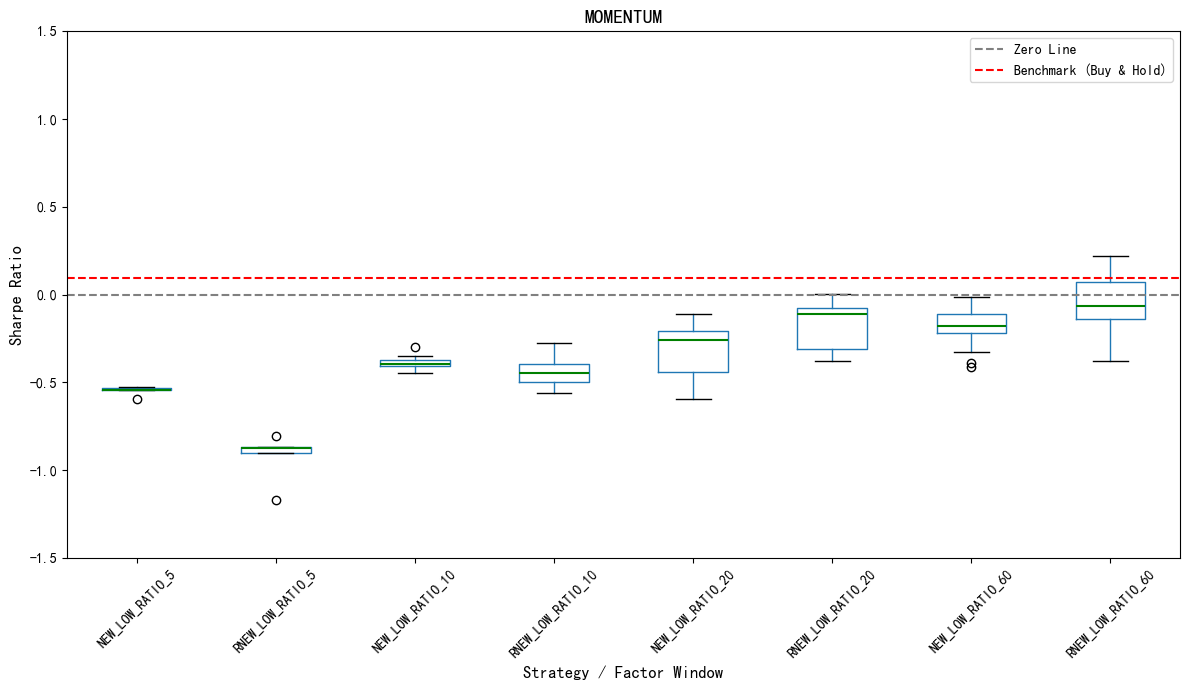

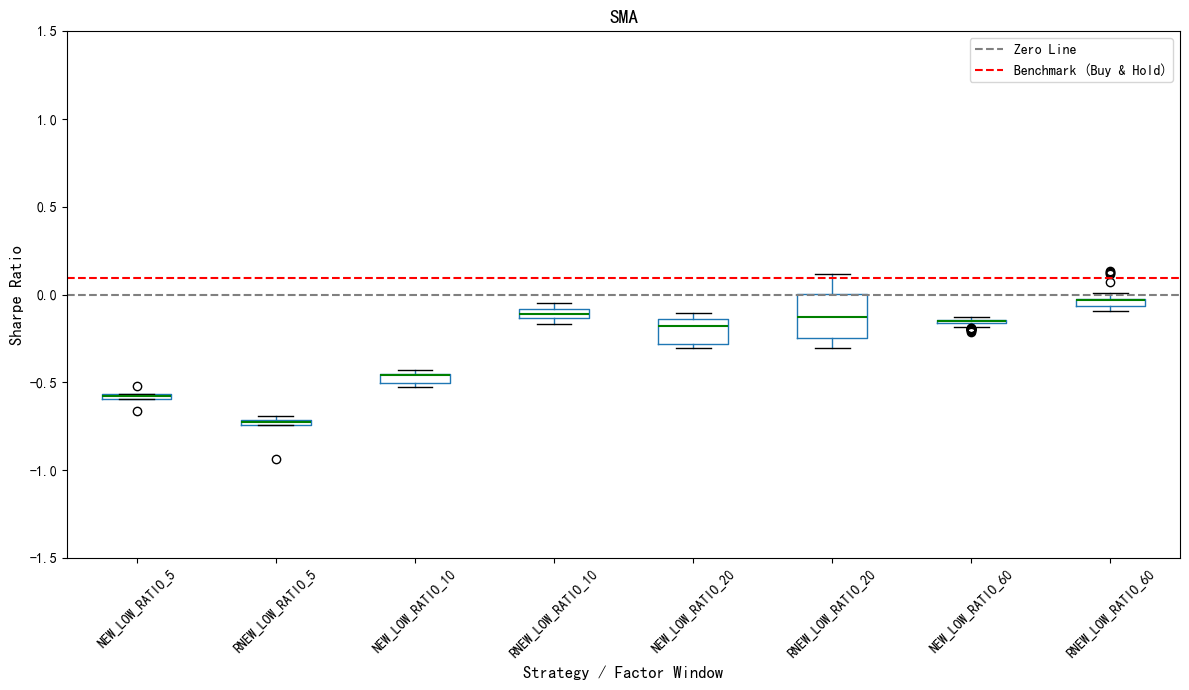

In [17]:
# 趋势新低占比
boll_results = boll.run_strategy("Close", "New_Low_Ratio", calc_new_low_ratio)
mom_results = mom.run_strategy("Close", "New_Low_Ratio", calc_new_low_ratio)
sma_results = sma.run_strategy("Close", "New_Low_Ratio", calc_new_low_ratio)

plot_box(boll_results, boll.sharpe_benchmark, "BOLL")
plot_box(mom_results, mom.sharpe_benchmark, "MOMENTUM")
plot_box(sma_results, sma.sharpe_benchmark, "SMA")

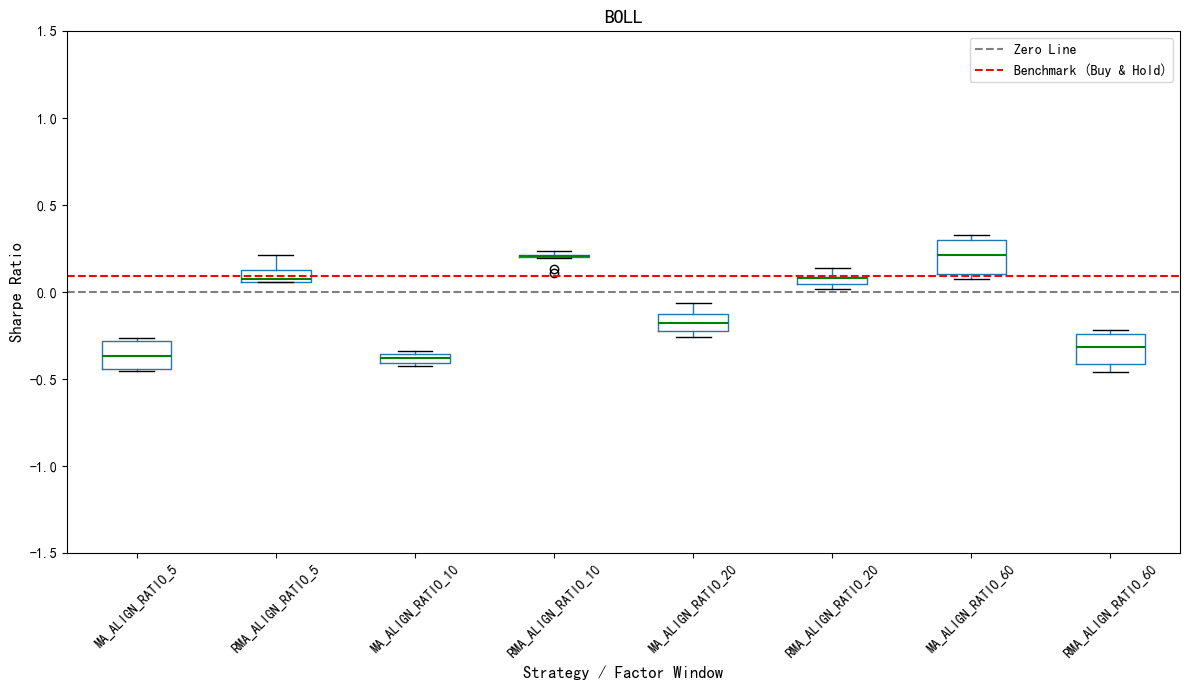

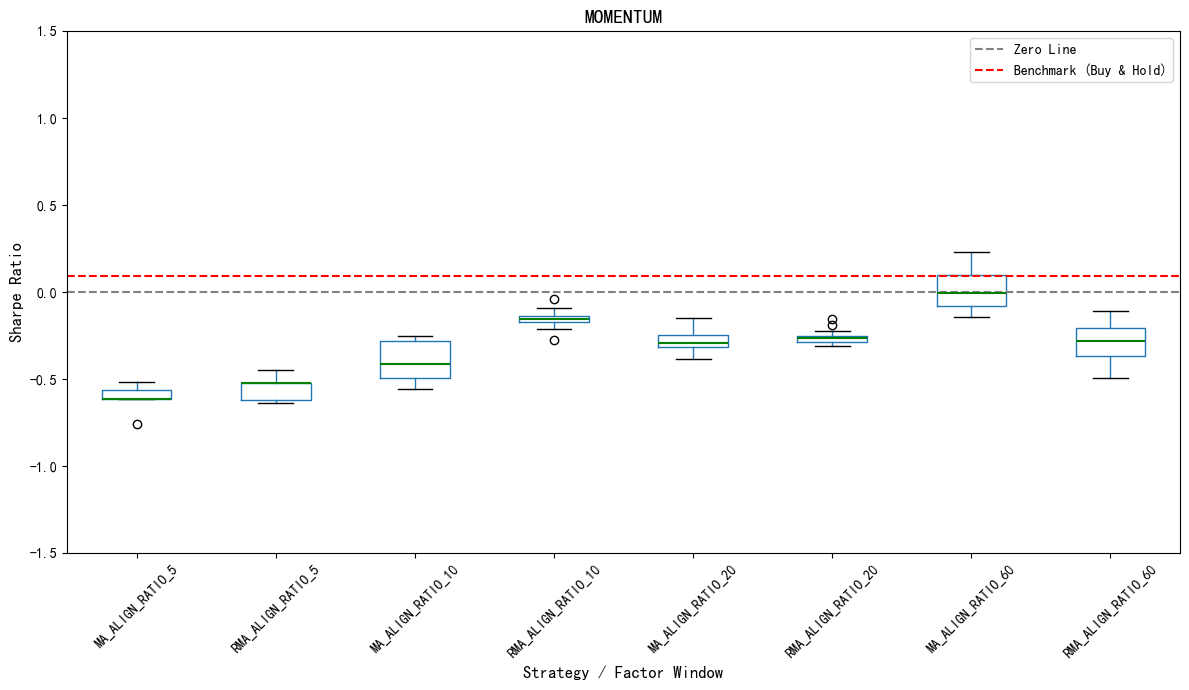

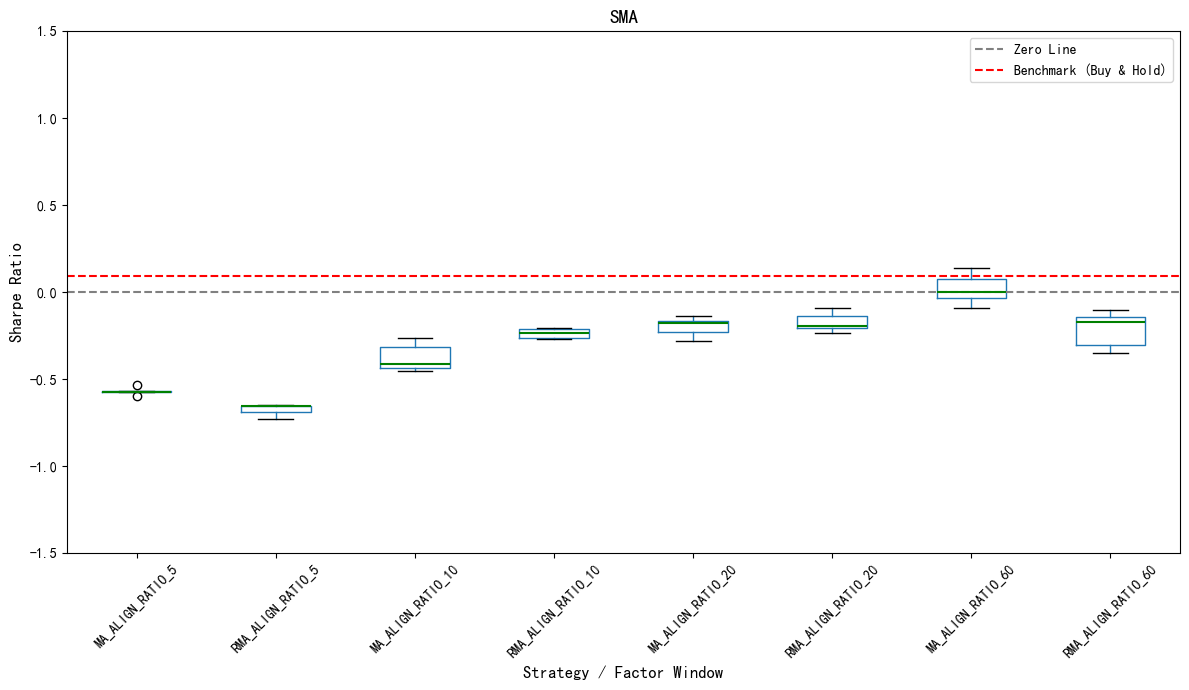

In [18]:
# 多头排列占比
boll_results = boll.run_strategy("Close", "MA_Align_Ratio", calc_ma_alignment_ratio)
mom_results = mom.run_strategy("Close", "MA_Align_Ratio", calc_ma_alignment_ratio)
sma_results = sma.run_strategy("Close", "MA_Align_Ratio", calc_ma_alignment_ratio)

plot_box(boll_results, boll.sharpe_benchmark, "BOLL")
plot_box(mom_results, mom.sharpe_benchmark, "MOMENTUM")
plot_box(sma_results, sma.sharpe_benchmark, "SMA")

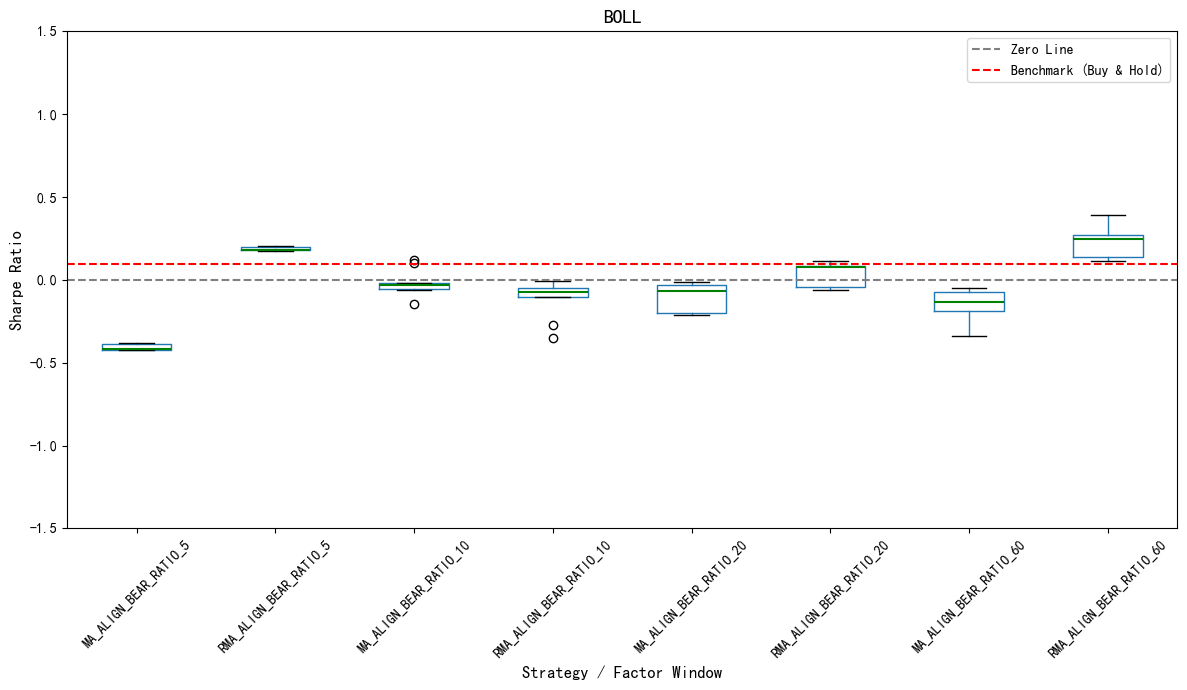

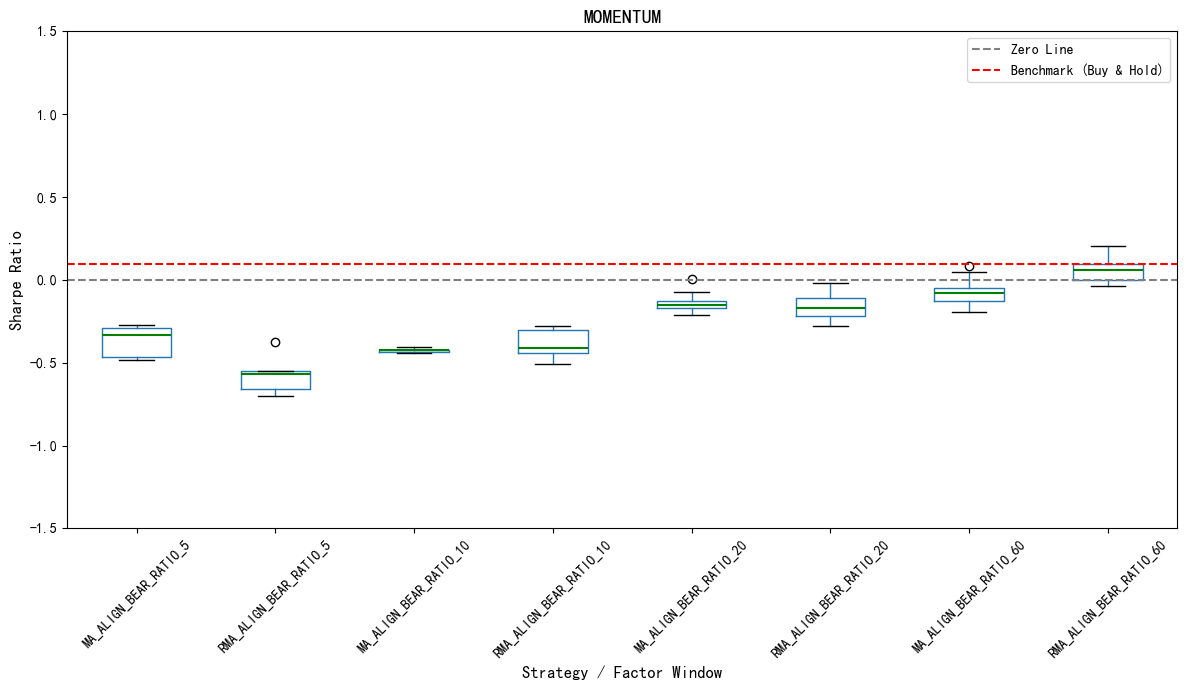

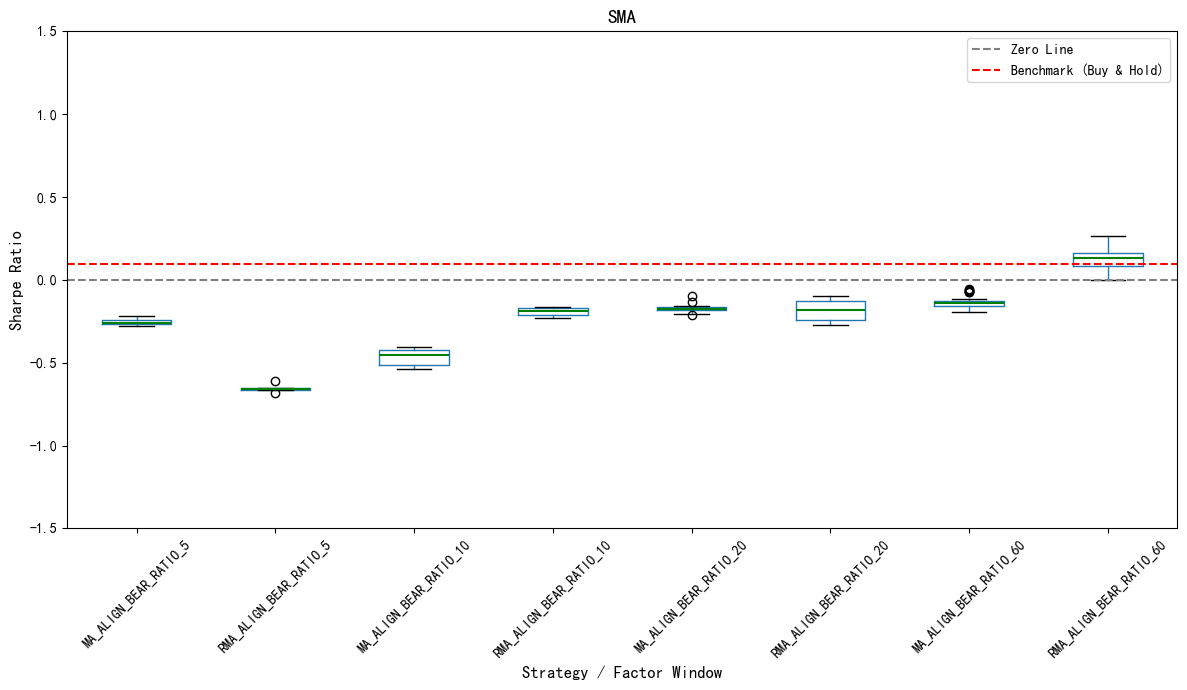

In [19]:
# 空头排列占比
boll_results = boll.run_strategy("Close", "MA_Align_Bear_Ratio", calc_ma_alignment_bear_ratio)
mom_results = mom.run_strategy("Close", "MA_Align_Bear_Ratio", calc_ma_alignment_bear_ratio)
sma_results = sma.run_strategy("Close", "MA_Align_Bear_Ratio", calc_ma_alignment_bear_ratio)

plot_box(boll_results, boll.sharpe_benchmark, "BOLL")
plot_box(mom_results, mom.sharpe_benchmark, "MOMENTUM")
plot_box(sma_results, sma.sharpe_benchmark, "SMA")

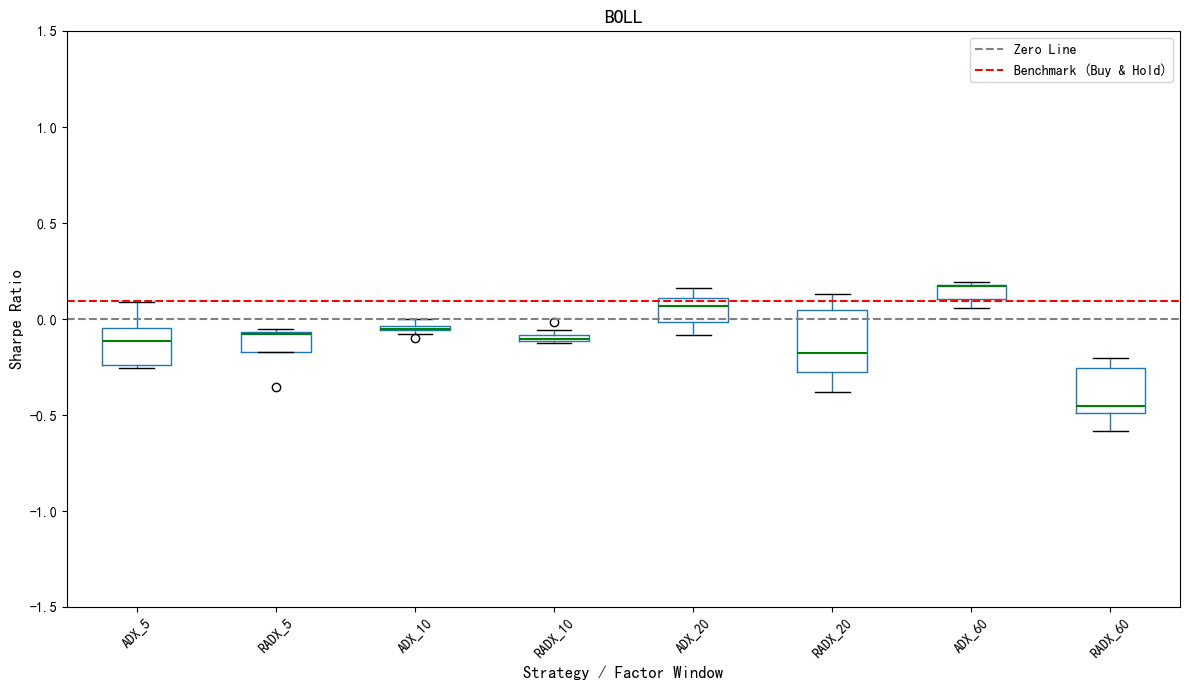

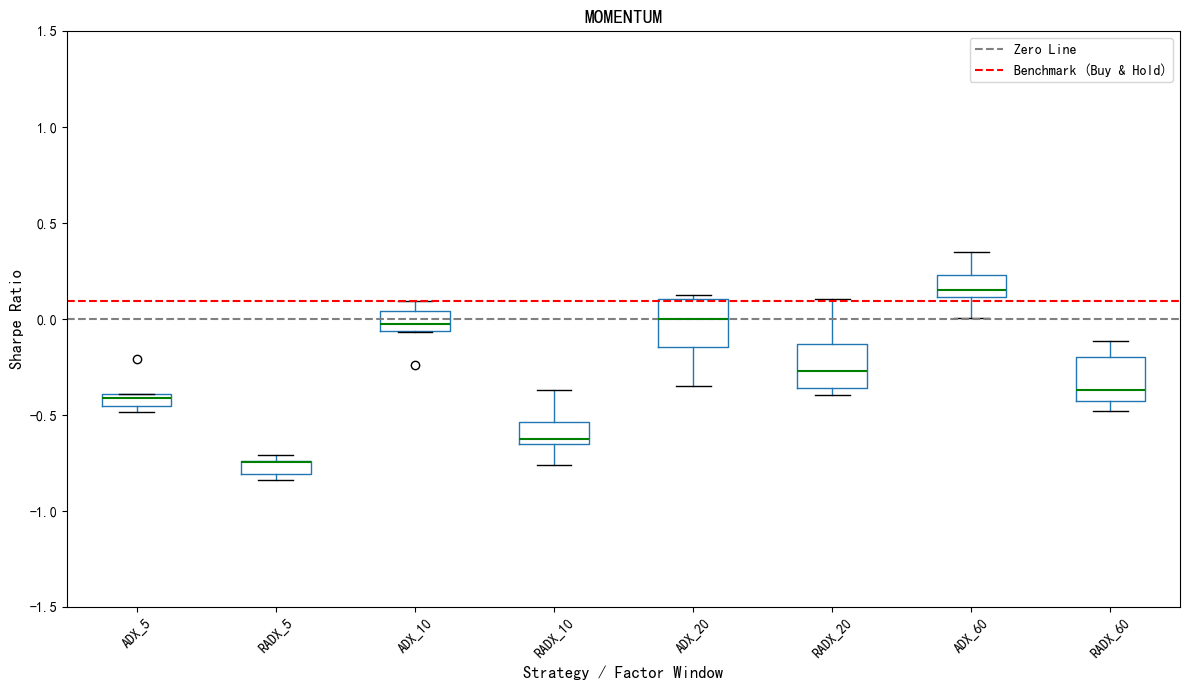

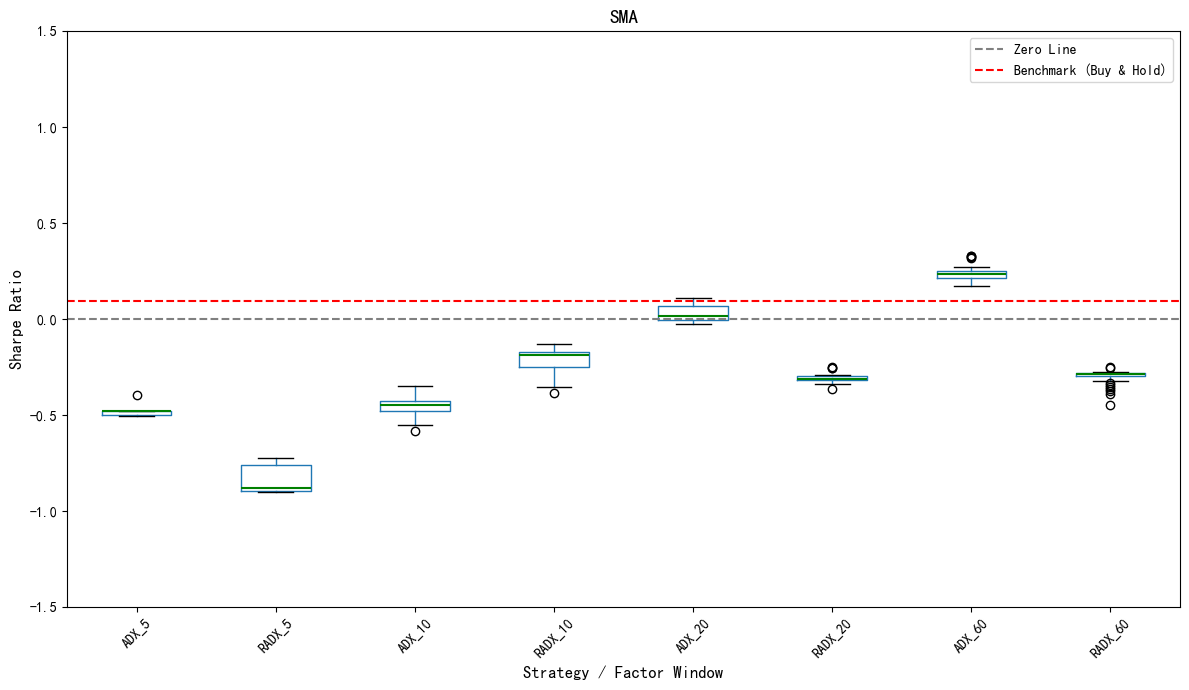

In [20]:
# ADX
boll_results = boll.run_strategy(["High", "Low", "Close"], "ADX", calc_adx)
mom_results = mom.run_strategy(["High", "Low", "Close"], "ADX", calc_adx)
sma_results = sma.run_strategy(["High", "Low", "Close"], "ADX", calc_adx)

plot_box(boll_results, boll.sharpe_benchmark, "BOLL")
plot_box(mom_results, mom.sharpe_benchmark, "MOMENTUM")
plot_box(sma_results, sma.sharpe_benchmark, "SMA")

#### 波动因子

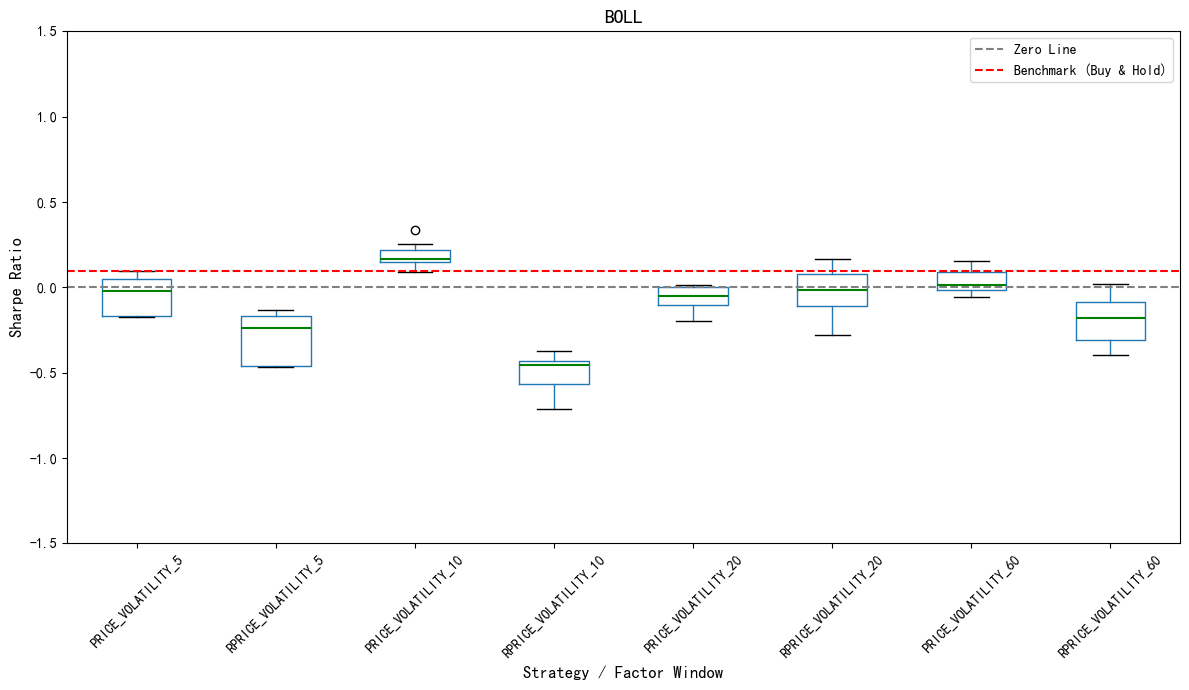

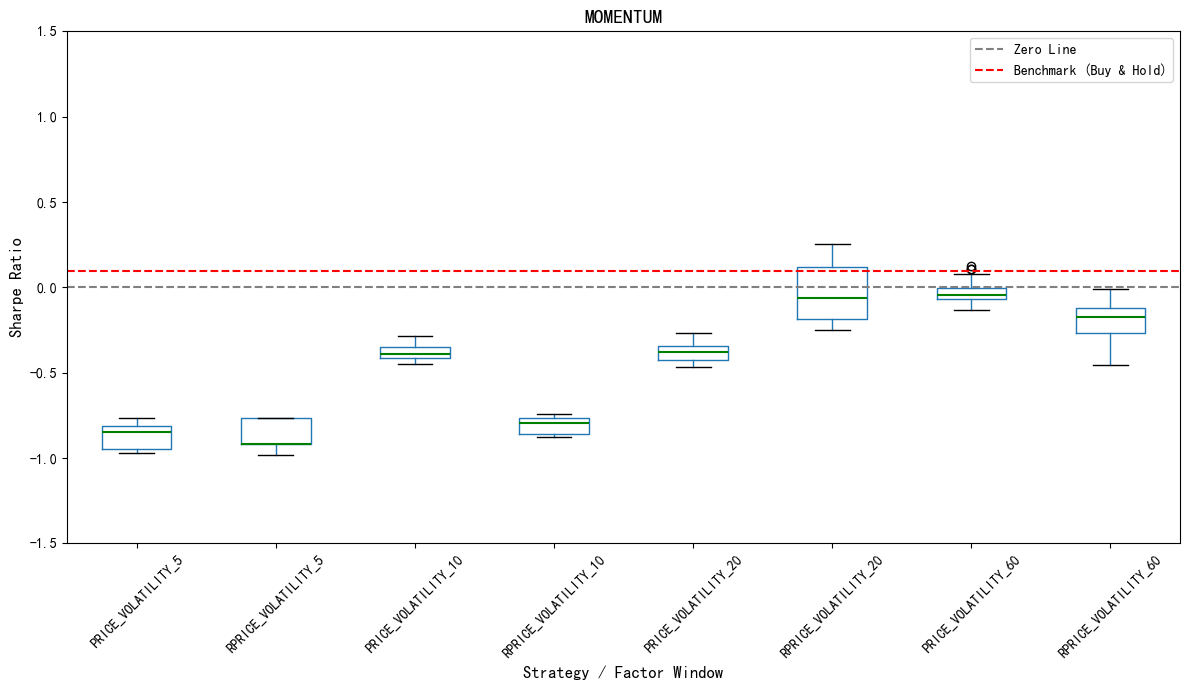

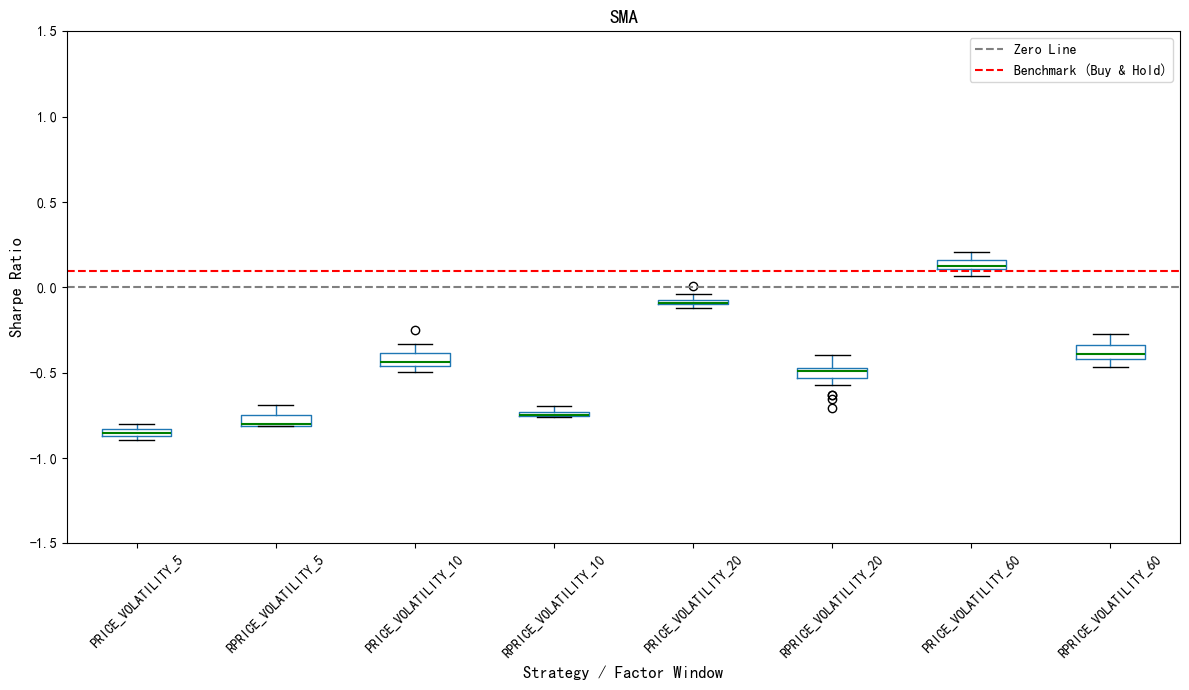

In [21]:
# 价格N日实际波动率
boll_results = boll.run_strategy("Close", "price_volatility", calc_price_volatility)
mom_results = mom.run_strategy("Close", "price_volatility", calc_price_volatility)
sma_results = sma.run_strategy("Close", "price_volatility", calc_price_volatility)

plot_box(boll_results, boll.sharpe_benchmark, "BOLL")
plot_box(mom_results, mom.sharpe_benchmark, "MOMENTUM")
plot_box(sma_results, sma.sharpe_benchmark, "SMA")

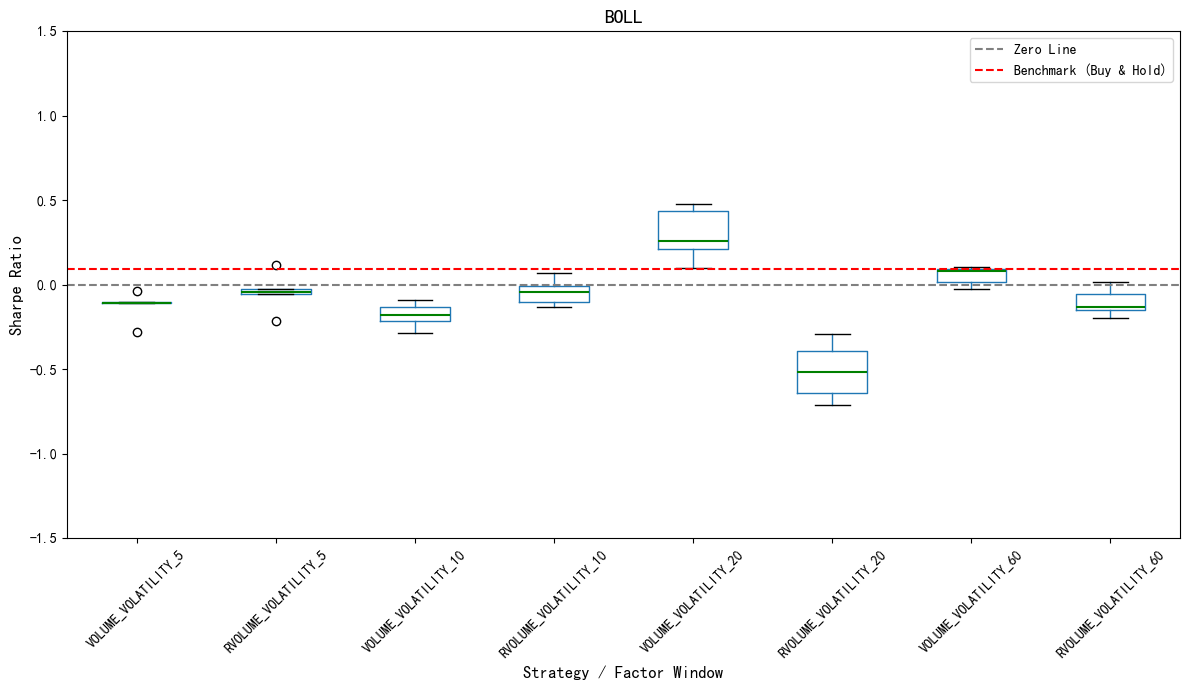

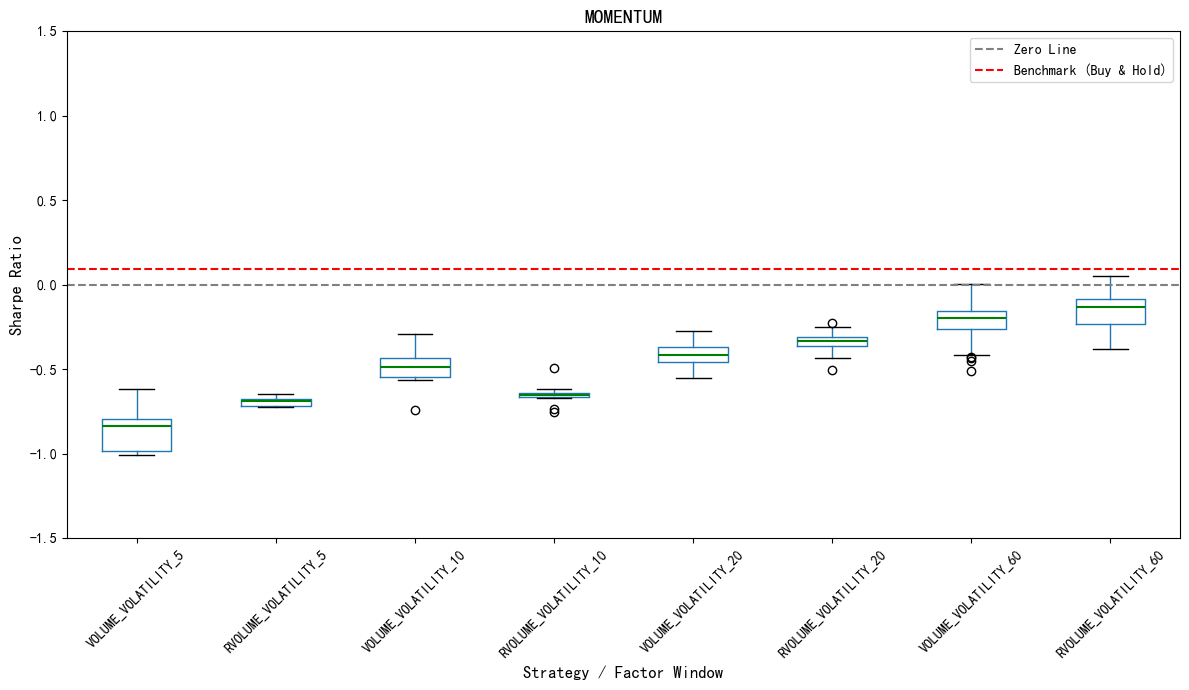

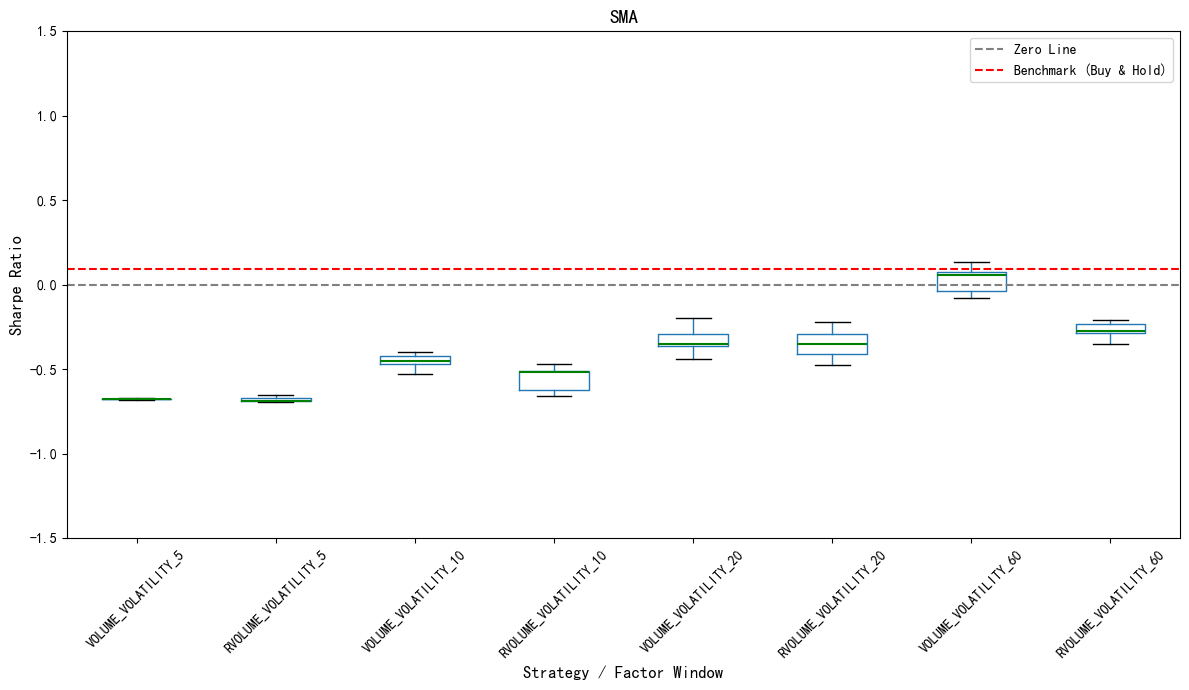

In [22]:
# 价格N日实际波动率
boll_results = boll.run_strategy("Volume", "volume_volatility", calc_volume_volatility)
mom_results = mom.run_strategy("Volume", "volume_volatility", calc_volume_volatility)
sma_results = sma.run_strategy("Volume", "volume_volatility", calc_volume_volatility)

plot_box(boll_results, boll.sharpe_benchmark, "BOLL")
plot_box(mom_results, mom.sharpe_benchmark, "MOMENTUM")
plot_box(sma_results, sma.sharpe_benchmark, "SMA")

### 测试因子收益

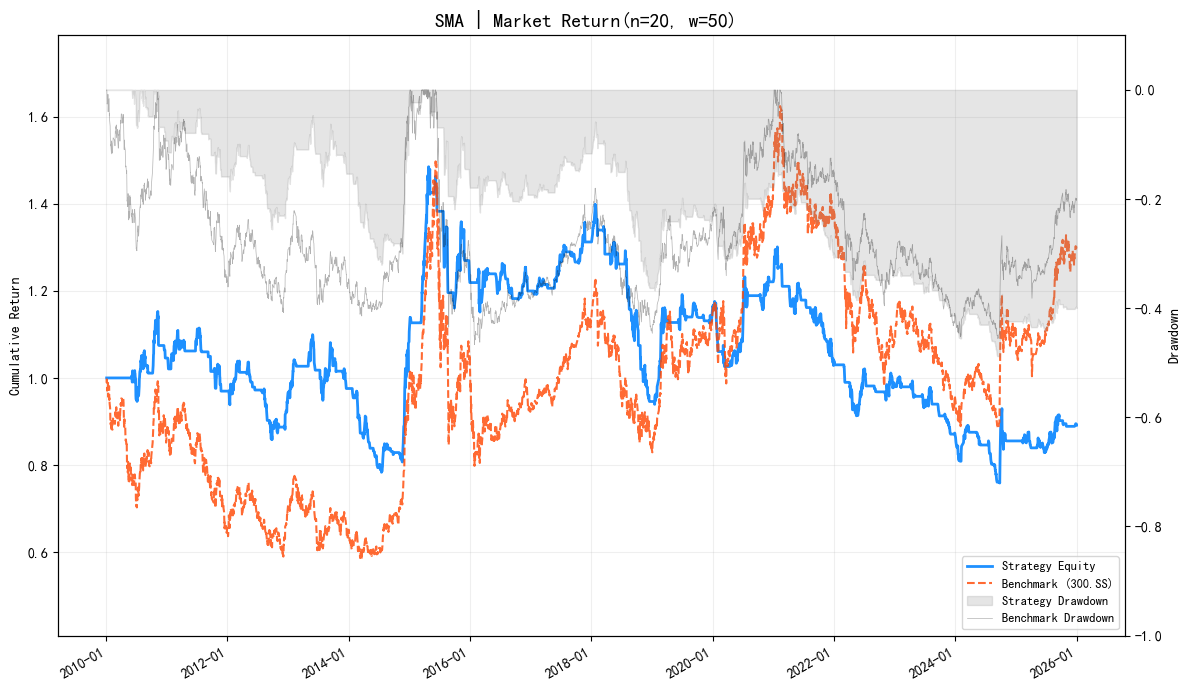

In [23]:
# SMA 策略，20 天市场收益率，50 天回看窗口
sma.plot_strategy_performance("Close", "Market Return", calc_momentum, 20, 50)

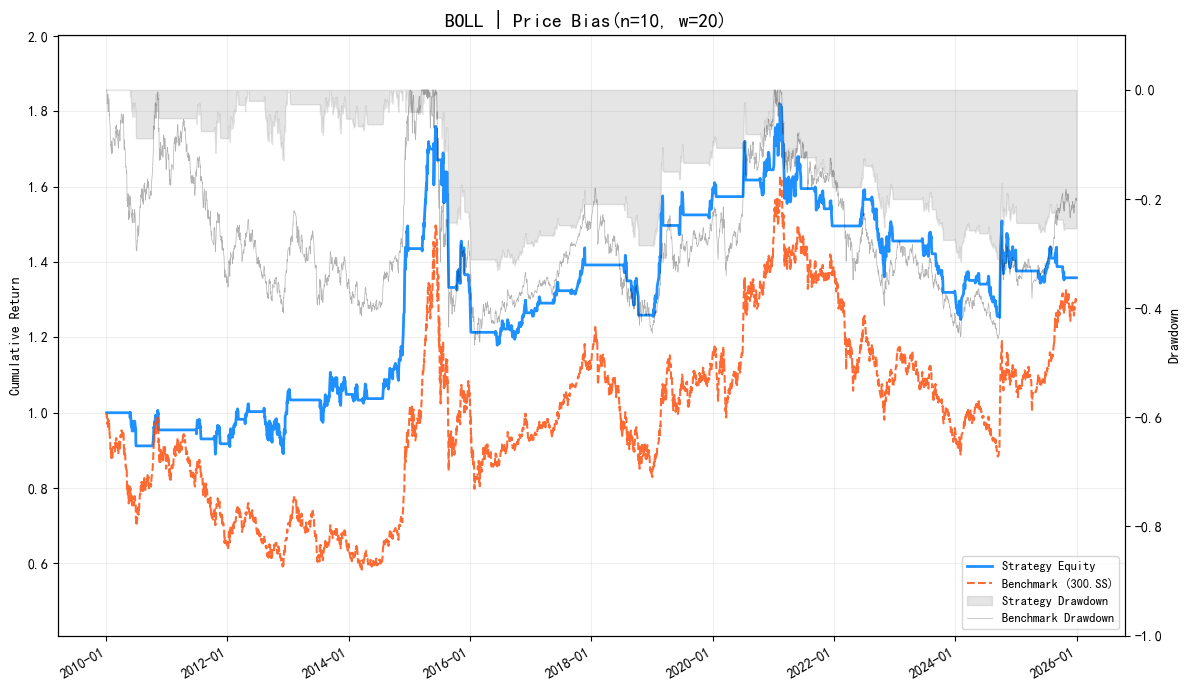

In [24]:
# BOLL 策略，10 天价格背离率，20 天回看窗口
boll.plot_strategy_performance("Close", "Price Bias", calc_price_bias, 10, 20)

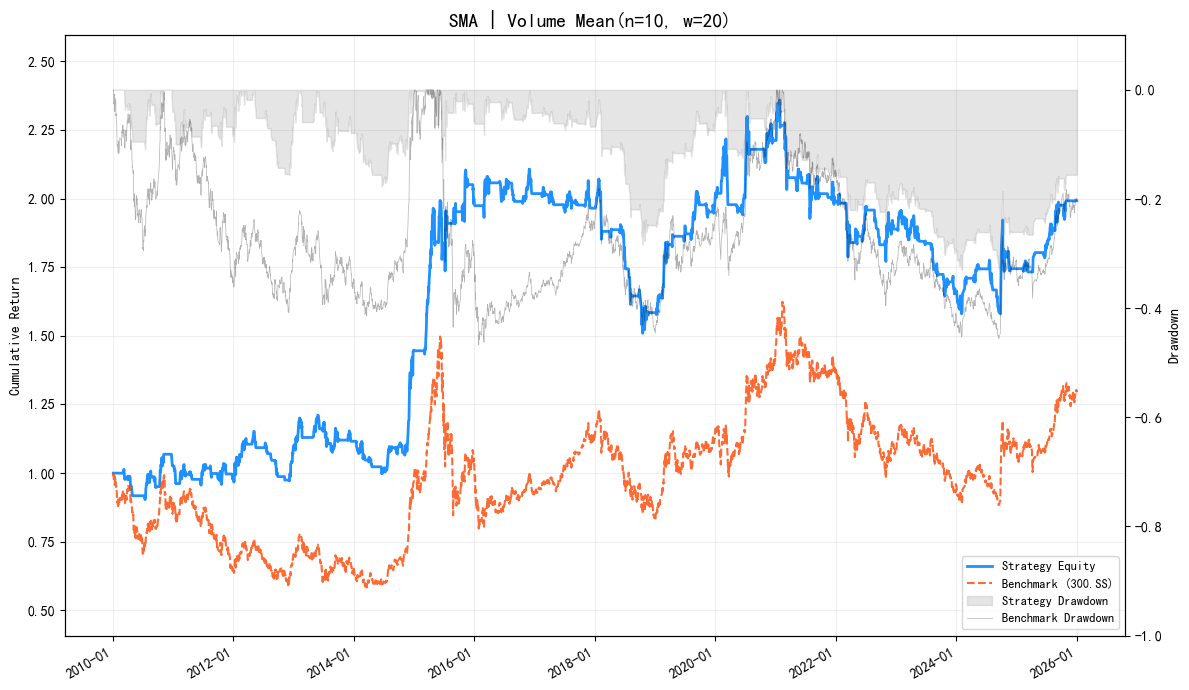

In [25]:
# SMA 策略，10 天成交量平均值，20 天回看窗口
sma.plot_strategy_performance("Volume", "Volume Mean", calc_vol_mean, 10, 20)

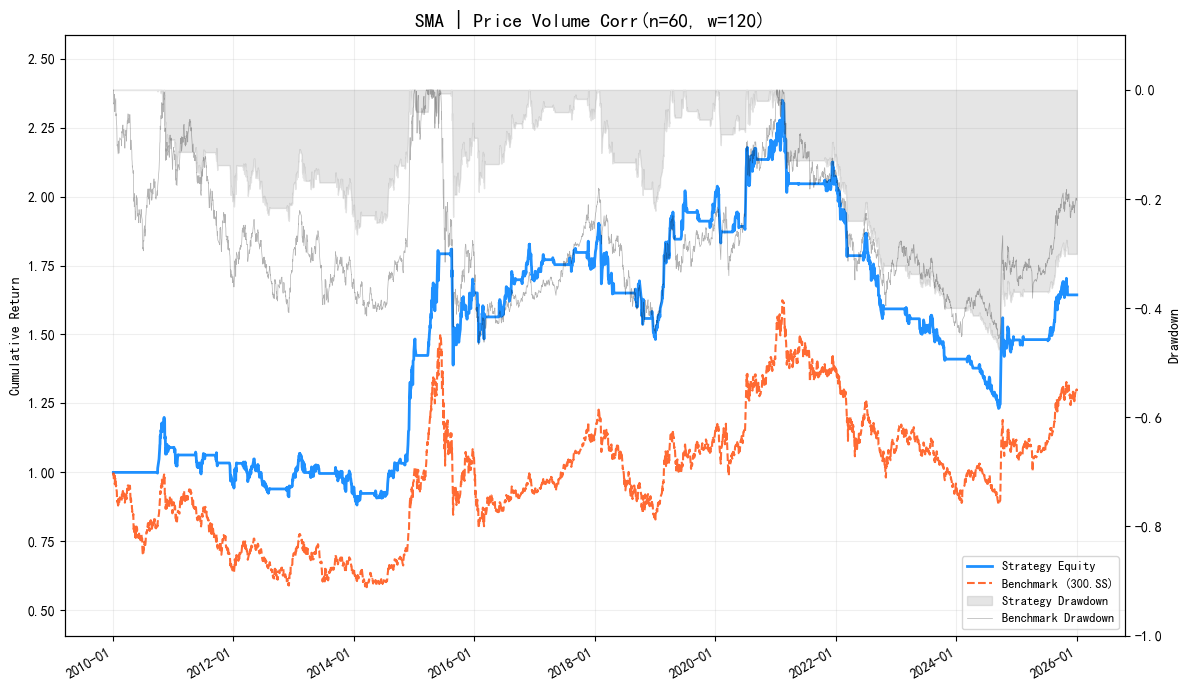

In [26]:
# BOLL 策略，60 日量价秩相关系数，120 天回看窗口
sma.plot_strategy_performance(["Close", "Volume"], 'Price Volume Corr',
                               calc_price_vol_corr, 60, 120)

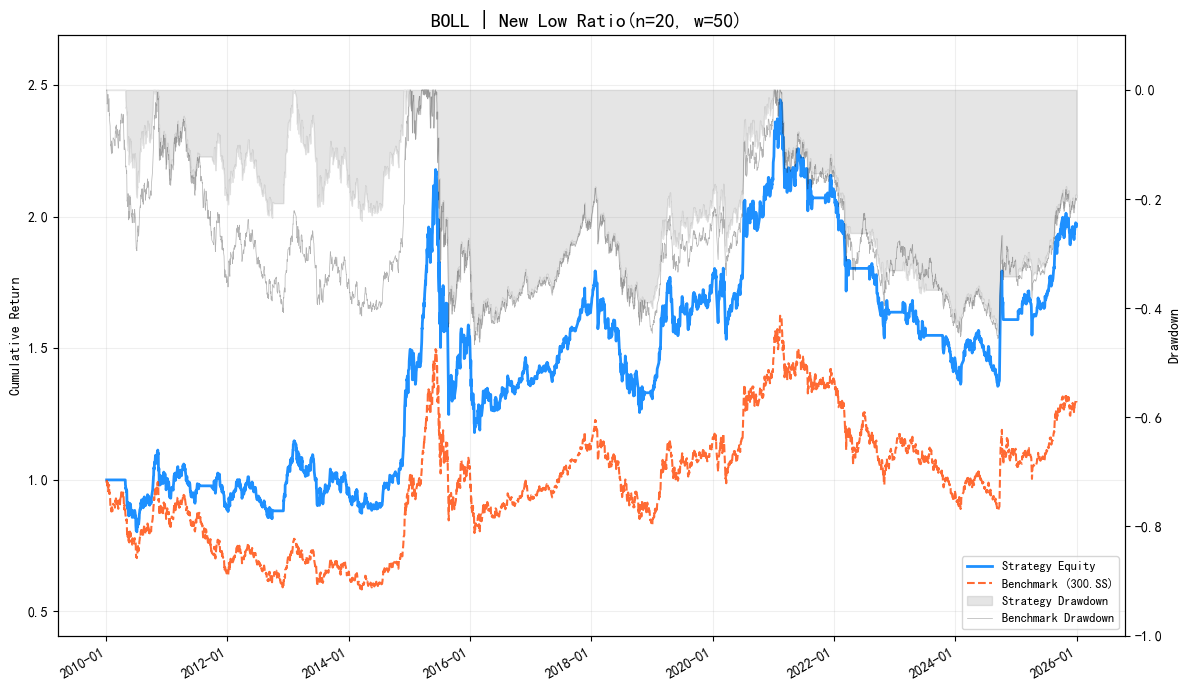

In [27]:
# BOLL 策略，20 日新低占比，50 天回看窗口
boll.plot_strategy_performance("Close", "New Low Ratio", calc_new_low_ratio, 20, 50)

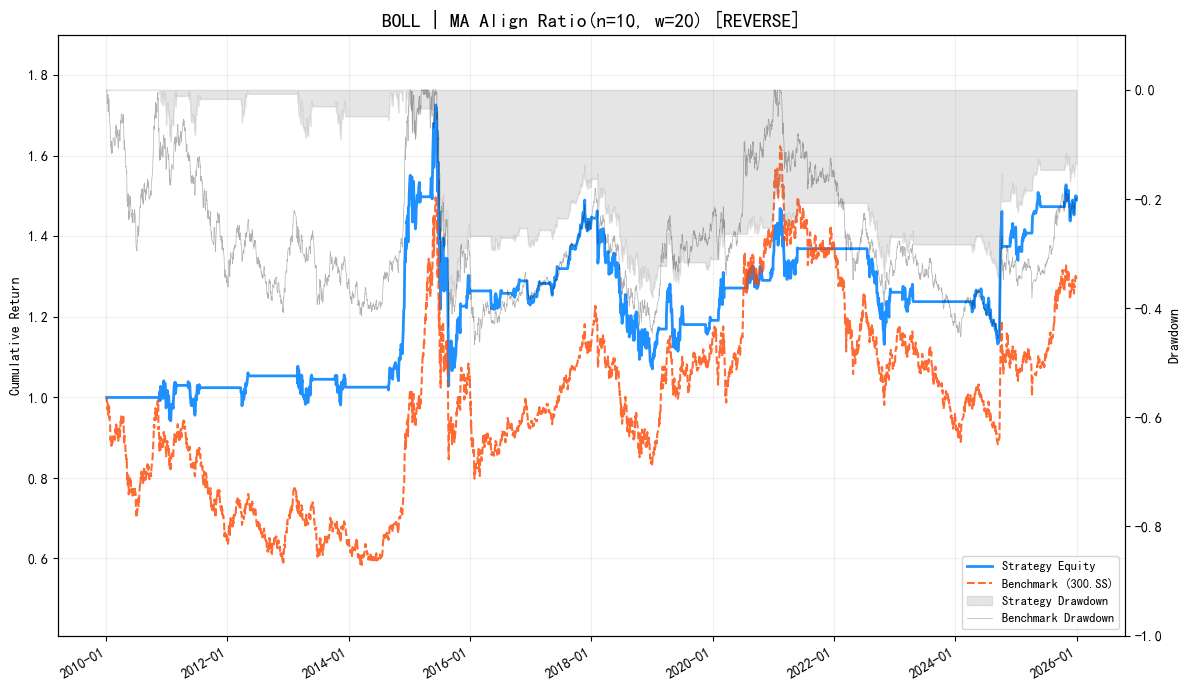

In [28]:
# Reverse BOLL 策略，10 日多头排列占比，20 天回看窗口
boll.plot_strategy_performance("Close", "MA Align Ratio", calc_ma_alignment_ratio,
                               10, 20, True)

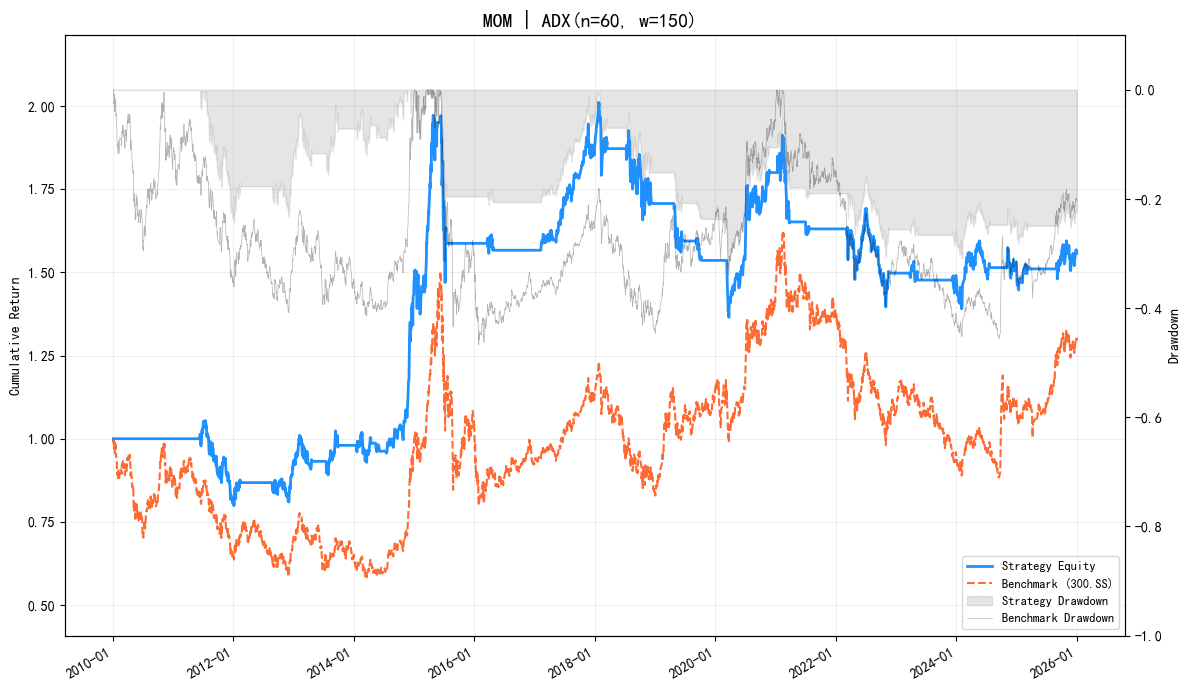

In [29]:
# MOMENTUM 策略，60 日ADX，150 天回看窗口
mom.plot_strategy_performance(["High", "Low", "Close"], "ADX", calc_adx, 60, 150)

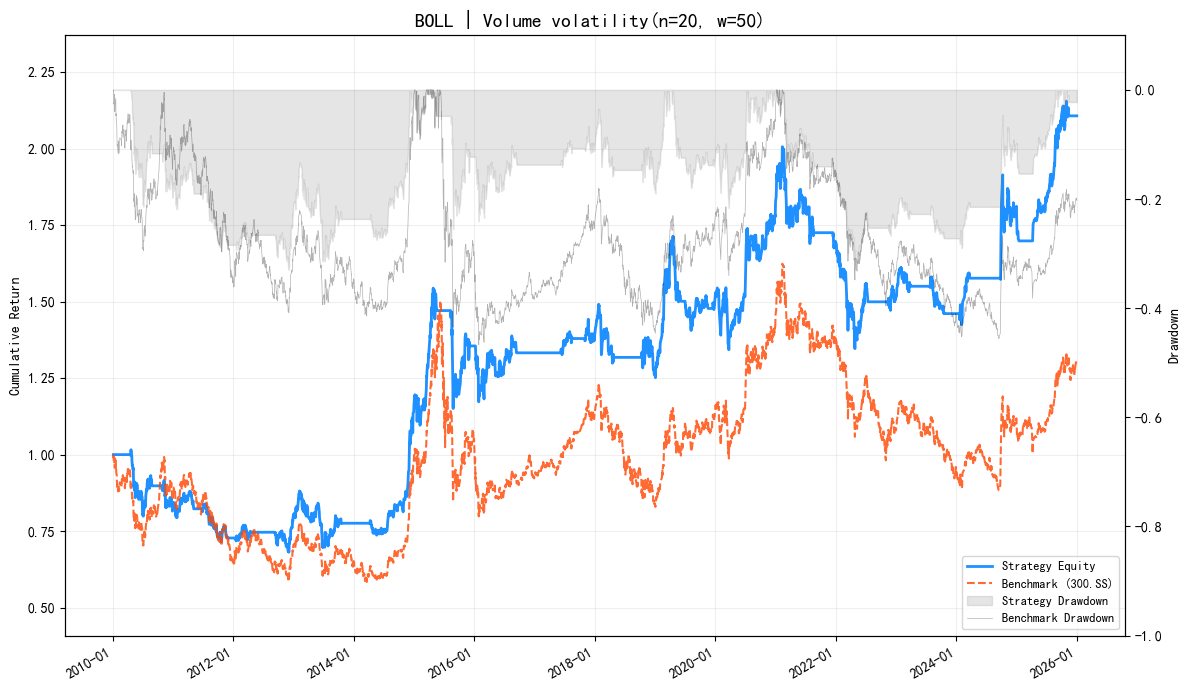

In [30]:
# BOLL 策略，价格 20 日实际波动率，50 天回看窗口
boll.plot_strategy_performance("Volume", "Volume volatility", calc_volume_volatility,
                               20, 50)

### 组合信号回测

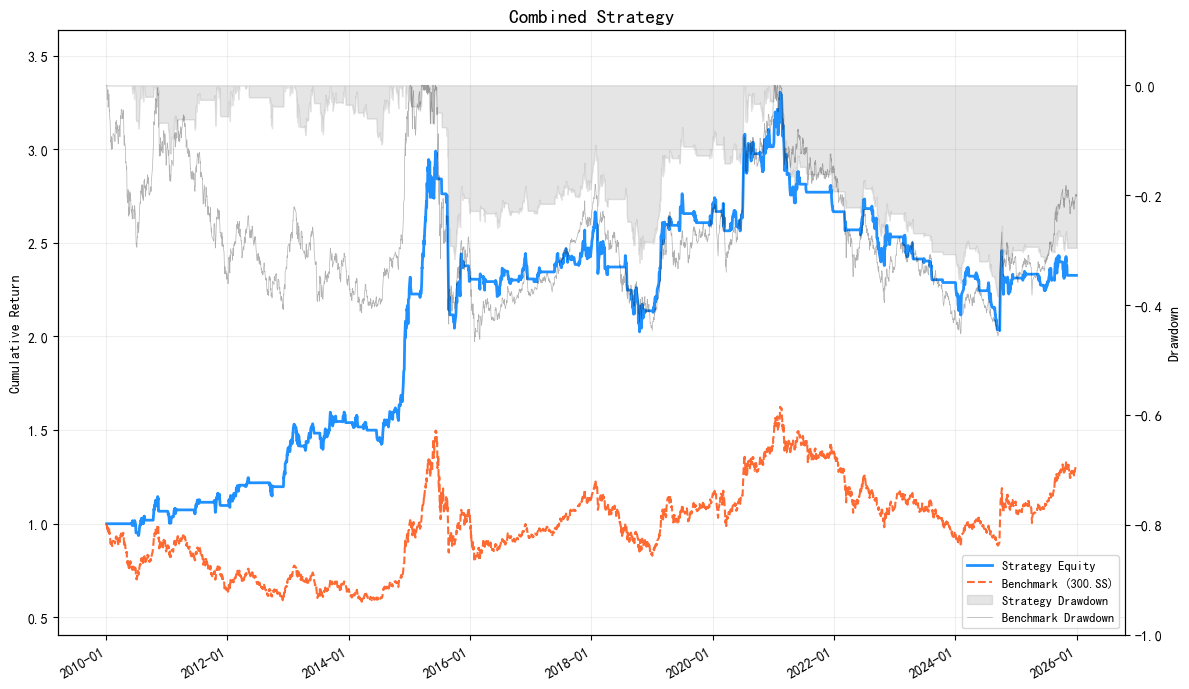

In [31]:
sig_1 = sma.get_strategy_signal("Close", "Market_Return_SMA", calc_momentum, 20, 50)

sig_2 = boll.get_strategy_signal("Close", "Price_Bias_BOLL", calc_price_bias, 10, 20)

sig_3 = sma.get_strategy_signal("Volume", "Volume_Mean_SMA", calc_vol_mean, 10, 20)

sig_4 = sma.get_strategy_signal(["Close", "Volume"], "Price_Vol_Corr_SMA",
                                calc_price_vol_corr, 60, 120)

sig_5 = boll.get_strategy_signal("Close", "New_Low_Ratio_BOLL", calc_new_low_ratio, 20, 50)

sig_6 = boll.get_strategy_signal("Close", "MA_Align_Ratio_RevBOLL",
                                 calc_ma_alignment_ratio, 10, 20, is_reverse=True)

sig_7 = mom.get_strategy_signal(["High", "Low", "Close"], "ADX_MOM", calc_adx, 60, 150)

sig_8 = boll.get_strategy_signal("Volume", "Volume_Volatility_BOLL",
                                 calc_volume_volatility, 20, 50)


all_signals_df = pd.concat([sig_1, sig_2, sig_3, sig_4, sig_5, sig_6, sig_7, sig_8],
                           axis=1)
all_signals_df.dropna(inplace=True)

all_signals_df['Average_Score'] = all_signals_df.mean(axis=1)

# 净有效指标大于 1 即进行操作
THRESHOLD = 0.125
combined_signal = np.where(all_signals_df['Average_Score'] > THRESHOLD, 1,
                                   np.where(all_signals_df['Average_Score'] < -THRESHOLD, -1, 0))

boll.plot_signal_performance(combined_signal)